In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("/content/drive/MyDrive/Datasets/SIH/ML_READY.csv")

In [6]:
df.head()

,Project_ID,Project_Name,Ministry,Sector,State,Start_Date,Target_DOC,Original_Cost_Cr,Cumulative_Expenditure_Cr,Physical_Progress_Pct,Expenditure_Pct_of_Original_Cost,Revised_Cost_Cr,Cost_Overrun_Cr,Cost_Overrun_Pct,Cost_Overrun_Flag,Revised_DOC,Time_Overrun_Days,Time_Overrun_Months,Time_Overrun_Flag
0,400006,Jharsuguda-Barpali-Sardega Ph II Works- Rail C...,Ministry of Railways,Railways,Odisha,10/1/2021,10/1/2025,808.99,743.46,40.00,91.8998,808.99,0.0,0.0000,0.0,12/1/2026,426.0,14.00,1.0
1,400010,Construction of Terminal Building & Associated...,Ministry of Civil Aviation,Aviation & Aviation Infrastructure,Ladakh,9/1/2018,9/1/2021,480.00,506.13,79.20,105.4437,640.00,160.0,33.3333,1.0,7/1/2026,1764.0,57.95,1.0
2,400012,Kandla Gorakhpur LPG Pipeline (Ministry of Pet...,Ministry of Petroleum & Natural Gas,Energy Storage,"Multi-States (Gujarat, Madhya Pradesh, Uttar P...",12/1/2018,12/1/2021,10088.00,8585.71,95.40,85.1081,10088.00,0.0,0.0000,0.0,6/1/2026,1643.0,53.98,1.0
3,400013,Saturation 4G mobile coverage of Uncovered Vil...,Department of Telecommunications,Telecommunication,PAN India,7/1/2022,6/1/2024,26316.00,9791.80,85.00,37.2085,15392.80,-10923.2,-41.5078,0.0,3/1/2027,1003.0,32.95,1.0
4,400018,HURA C OCP (ECL - CIL) (400018) (N06000275) (4...,Ministry of Coal,Coal,Jharkhand,8/1/2022,3/1/2029,859.41,455.25,63.22,52.9724,859.41,0.0,0.0000,0.0,NaN,NaN,NaN,NaN


In [7]:
# Time Overrun Regression Dataset

reg_df = df.copy()

print("Original Shape:", reg_df.shape)

Original Shape: (1966, 19)


In [8]:
print("Time Overrun Days - Missing Values:")
print(reg_df["Time_Overrun_Days"].isnull().sum())

print("\nTime Overrun Days - Valid Values:")
print(reg_df["Time_Overrun_Days"].notnull().sum())

print("\nBasic Statistics:")
print(reg_df["Time_Overrun_Days"].describe())

Time Overrun Days - Missing Values:
353

Time Overrun Days - Valid Values:
1613

Basic Statistics:
count     1613.000000
mean       706.132672
std        962.511107
min     -10837.000000
25%         92.000000
50%        457.000000
75%        973.000000
max       9131.000000
Name: Time_Overrun_Days, dtype: float64


In [9]:

negative_overrun = reg_df[
    reg_df["Time_Overrun_Days"] < 0
]

print("Negative Time Overrun Records:",
      len(negative_overrun))

print("\nNegative values:")
print(
    negative_overrun[
        [
            "Project_ID",
            "Project_Name",
            "Target_DOC",
            "Revised_DOC",
            "Time_Overrun_Days",
            "Time_Overrun_Months"
        ]
    ].head(20)
)

Negative Time Overrun Records: 43

Negative values:
     Project_ID                                       Project_Name Target_DOC  \
11       400045  Proposed 6 nos Road Over Bridge [ROB] at diffe...   3/1/2025   
65       400203  Dharamjaigarh-Korba (Railway) (400203) (-) (2277)  12/1/2026   
119      603293  Badam Coal Mining project of NTPC (National Th...  12/1/2056   
220      612876  Construction of Permanent Campus for NIT Mizor...  12/1/2029   
223      612883  Establishment of Permanent Campus of NIT SIkki...   2/1/2028   
226      612898  Construction of Permanent Campus of National I...   8/1/2026   
258      615202  Capacity expansion of Deposit-14 and 14 NMZ at...  12/1/2028   
419      617409  Railway Manufacturing Unit (RVNL - II) (617409...  12/1/2026   
440      617829  LPG Bottling Plant at Mualkhang (Ministry of P...  10/1/2028   
538      617979  Rehabilitation, upgradation & widening of exis...   5/1/2027   
714      618178  Widening and strengthening of Gangakhed 

In [10]:
# Remove negative Time Overrun values
reg_df_clean = reg_df[
    reg_df["Time_Overrun_Days"] >= 0
].copy()

print("Original rows :", len(reg_df))
print("Clean rows    :", len(reg_df_clean))
print("Removed rows  :", len(reg_df) - len(reg_df_clean))

Original rows : 1966
Clean rows    : 1570
Removed rows  : 396


In [11]:
print(reg_df_clean["Time_Overrun_Days"].describe())

count    1570.000000
mean      746.705096
std       900.710192
min         0.000000
25%       123.000000
50%       486.000000
75%       975.000000
max      9131.000000
Name: Time_Overrun_Days, dtype: float64


In [12]:
# Remove negative Time Overrun values
reg_df_clean = reg_df[
    reg_df["Time_Overrun_Days"] >= 0
].copy()

# Basic information
print("Original rows :", len(reg_df))
print("Clean rows    :", len(reg_df_clean))
print("Removed rows  :", len(reg_df) - len(reg_df_clean))

# Statistics
print("\nTime Overrun Statistics:")
print(reg_df_clean["Time_Overrun_Days"].describe())


Original rows : 1966
Clean rows    : 1570
Removed rows  : 396

Time Overrun Statistics:
count    1570.000000
mean      746.705096
std       900.710192
min         0.000000
25%       123.000000
50%       486.000000
75%       975.000000
max      9131.000000
Name: Time_Overrun_Days, dtype: float64


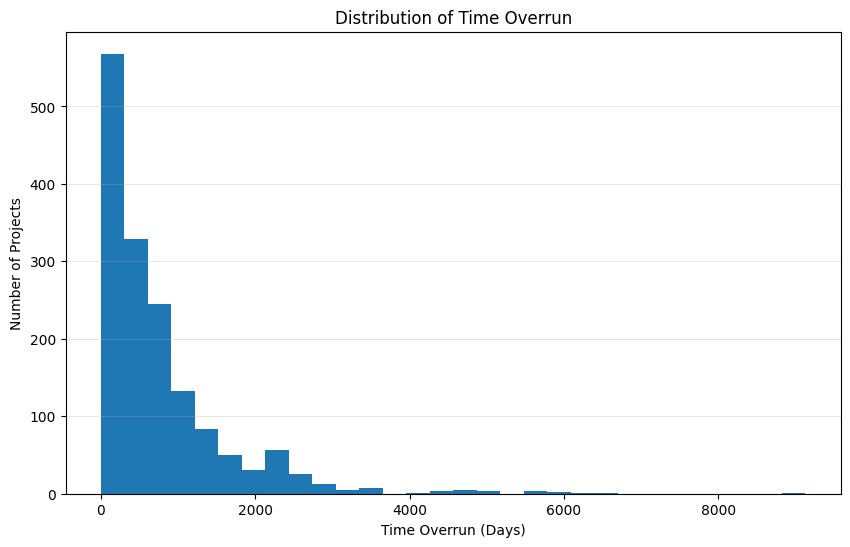

In [13]:
plt.figure(figsize=(10, 6))

plt.hist(
    reg_df_clean["Time_Overrun_Days"],
    bins=30
)

plt.xlabel("Time Overrun (Days)")
plt.ylabel("Number of Projects")
plt.title("Distribution of Time Overrun")

plt.grid(axis="y", alpha=0.3)

plt.show()

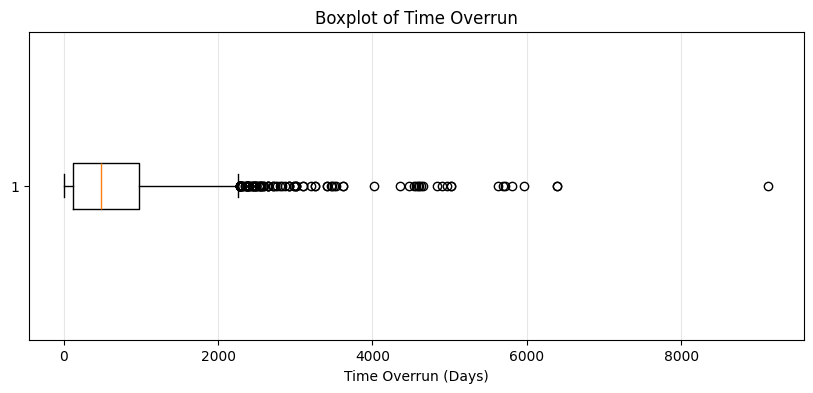

In [14]:
plt.figure(figsize=(10, 4))

plt.boxplot(
    reg_df_clean["Time_Overrun_Days"].dropna(),
    vert=False
)

plt.xlabel("Time Overrun (Days)")
plt.title("Boxplot of Time Overrun")

plt.grid(axis="x", alpha=0.3)

plt.show()

In [15]:
Q1 = reg_df_clean["Time_Overrun_Days"].quantile(0.25)
Q3 = reg_df_clean["Time_Overrun_Days"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

print("\nLower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

outliers = reg_df_clean[
    (reg_df_clean["Time_Overrun_Days"] < lower_bound) |
    (reg_df_clean["Time_Overrun_Days"] > upper_bound)
]

print("\nNumber of Outliers:", len(outliers))

Q1: 123.0
Q3: 975.0
IQR: 852.0

Lower Bound: -1155.0
Upper Bound: 2253.0

Number of Outliers: 104


In [16]:
# Create log-transformed target

reg_df_clean["Log_Time_Overrun_Days"] = np.log1p(
    reg_df_clean["Time_Overrun_Days"]
)

print(reg_df_clean[
    [
        "Time_Overrun_Days",
        "Log_Time_Overrun_Days"
    ]
].head(10))

    Time_Overrun_Days  Log_Time_Overrun_Days
0               426.0               6.056784
1              1764.0               7.475906
2              1643.0               7.404888
3              1003.0               6.911747
5               274.0               5.616771
6                 0.0               0.000000
7               699.0               6.551080
9               273.0               5.613128
10              304.0               5.720312
12              730.0               6.594413


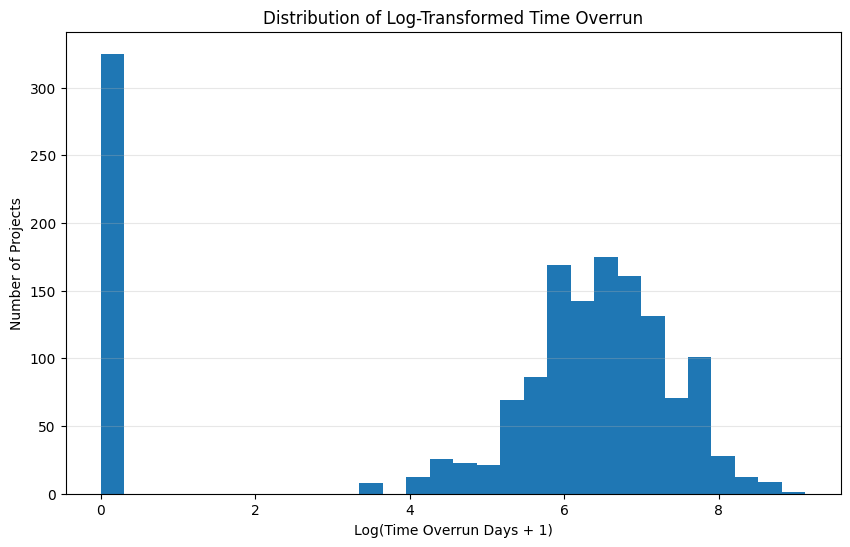

In [17]:
plt.figure(figsize=(10, 6))

plt.hist(reg_df_clean["Log_Time_Overrun_Days"],bins=30)

plt.xlabel("Log(Time Overrun Days + 1)")
plt.ylabel("Number of Projects")
plt.title("Distribution of Log-Transformed Time Overrun")

plt.grid(axis="y", alpha=0.3)

plt.show()

In [18]:
reg_features = [
    "Original_Cost_Cr",
    "Cumulative_Expenditure_Cr",
    "Physical_Progress_Pct",
    "Expenditure_Pct_of_Original_Cost",
    "Ministry",
    "Sector",
    "State"
]

X_reg = reg_df_clean[reg_features].copy()

print("Features selected:")
print(X_reg.columns.tolist())

print("\nShape of X:", X_reg.shape)

Features selected:
['Original_Cost_Cr', 'Cumulative_Expenditure_Cr', 'Physical_Progress_Pct', 'Expenditure_Pct_of_Original_Cost', 'Ministry', 'Sector', 'State']

Shape of X: (1570, 7)


In [19]:
# Check missing values in regression features

print("Missing values in each feature:\n")
print(X_reg.isnull().sum())

Missing values in each feature:

Original_Cost_Cr                    0
Cumulative_Expenditure_Cr           0
Physical_Progress_Pct               2
Expenditure_Pct_of_Original_Cost    0
Ministry                            0
Sector                              0
State                               0
dtype: int64


In [20]:
print("\nMissing percentage:\n")
print((X_reg.isnull().sum() / len(X_reg) * 100).round(2))


Missing percentage:

Original_Cost_Cr                    0.00
Cumulative_Expenditure_Cr           0.00
Physical_Progress_Pct               0.13
Expenditure_Pct_of_Original_Cost    0.00
Ministry                            0.00
Sector                              0.00
State                               0.00
dtype: float64


In [21]:
# Fill missing Physical Progress values with median

X_reg_clean = X_reg.copy()

median_physical_progress = X_reg_clean["Physical_Progress_Pct"].median()

X_reg_clean["Physical_Progress_Pct"] = (X_reg_clean["Physical_Progress_Pct"].fillna(median_physical_progress))

print("Median Physical Progress:",
      median_physical_progress)

print("\nRemaining missing values:")
print(X_reg_clean.isnull().sum())

Median Physical Progress: 79.5

Remaining missing values:
Original_Cost_Cr                    0
Cumulative_Expenditure_Cr           0
Physical_Progress_Pct               0
Expenditure_Pct_of_Original_Cost    0
Ministry                            0
Sector                              0
State                               0
dtype: int64


In [22]:
# Create regression target

y_reg = reg_df_clean["Log_Time_Overrun_Days"].copy()

print("Target column: Log_Time_Overrun_Days")
print("Target shape:", y_reg.shape)

print("\nFirst 10 target values:")
print(y_reg.head(10))

Target column: Log_Time_Overrun_Days
Target shape: (1570,)

First 10 target values:
0     6.056784
1     7.475906
2     7.404888
3     6.911747
5     5.616771
6     0.000000
7     6.551080
9     5.613128
10    5.720312
12    6.594413
Name: Log_Time_Overrun_Days, dtype: float64


In [23]:
from sklearn.model_selection import train_test_split

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg_clean,y_reg,test_size=0.20,random_state=42)

print("Training Features :", X_train_reg.shape)
print("Testing Features  :", X_test_reg.shape)

print("Training Target   :", y_train_reg.shape)
print("Testing Target    :", y_test_reg.shape)

Training Features : (1256, 7)
Testing Features  : (314, 7)
Training Target   : (1256,)
Testing Target    : (314,)


In [24]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [25]:
# Numerical features

numeric_features_reg = [
    "Original_Cost_Cr",
    "Cumulative_Expenditure_Cr",
    "Physical_Progress_Pct",
    "Expenditure_Pct_of_Original_Cost"
]

# Categorical features

categorical_features_reg = [
    "Ministry",
    "Sector",
    "State"
]

print("Numerical Features:")
print(numeric_features_reg)

print("\nCategorical Features:")
print(categorical_features_reg)

Numerical Features:
['Original_Cost_Cr', 'Cumulative_Expenditure_Cr', 'Physical_Progress_Pct', 'Expenditure_Pct_of_Original_Cost']

Categorical Features:
['Ministry', 'Sector', 'State']


In [26]:
# Numerical preprocessing
numeric_transformer_reg = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        )
    ]
)


# Categorical preprocessing
categorical_transformer_reg = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

In [27]:
preprocessor_reg = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_transformer_reg,
            numeric_features_reg
        ),
        (
            "categorical",
            categorical_transformer_reg,
            categorical_features_reg
        )
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [28]:
from sklearn.ensemble import RandomForestRegressor

In [29]:
rf_reg = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

print("Random Forest Regressor created successfully!")

Random Forest Regressor created successfully!


In [30]:
regression_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor_reg
        ),
        (
            "regressor",
            rf_reg
        )
    ]
)

print("Complete Regression Pipeline created!")

Complete Regression Pipeline created!


In [31]:
regression_model.fit(X_train_reg,y_train_reg)

print("Time Overrun Regression Model trained successfully!")

Time Overrun Regression Model trained successfully!


In [32]:
# Predict Time Overrun on test data

y_pred_log = regression_model.predict(X_test_reg)

print("First 10 Predicted Log Values:")
print(y_pred_log[:10])

First 10 Predicted Log Values:
[4.4055833  6.64258289 5.05964199 6.08890832 6.89825809 6.48240099
 3.82235344 4.69201974 2.15558671 4.11360009]


In [33]:
# Convert predicted log values back to actual days

y_pred_days = np.expm1(y_pred_log)

print("First 10 Predicted Time Overrun Days:")
print(np.round(y_pred_days[:10], 2))

First 10 Predicted Time Overrun Days:
[ 80.91 766.07 156.53 439.94 989.55 652.54  44.71 108.07   7.63  60.17]


In [34]:
# Compare actual and predicted Time Overrun

comparison_df = pd.DataFrame({
    "Actual_Time_Overrun_Days": y_test_reg.values,
    "Predicted_Time_Overrun_Days": y_pred_days
})

comparison_df["Difference_Days"] = (
    comparison_df["Actual_Time_Overrun_Days"]
    - comparison_df["Predicted_Time_Overrun_Days"]
)

comparison_df.head(10)

,Actual_Time_Overrun_Days,Predicted_Time_Overrun_Days,Difference_Days
0,7.287561,80.906905,-73.619345
1,6.190315,766.073707,-759.883392
2,5.902633,156.534107,-150.631474
3,5.214936,439.939784,-434.724849
4,8.194782,989.547766,-981.352985
5,6.594413,652.538200,-645.943787
6,6.881411,44.711662,-37.830250
7,6.190315,108.073258,-101.882942
8,0.000000,7.632954,-7.632954
9,5.370638,60.166527,-54.795889


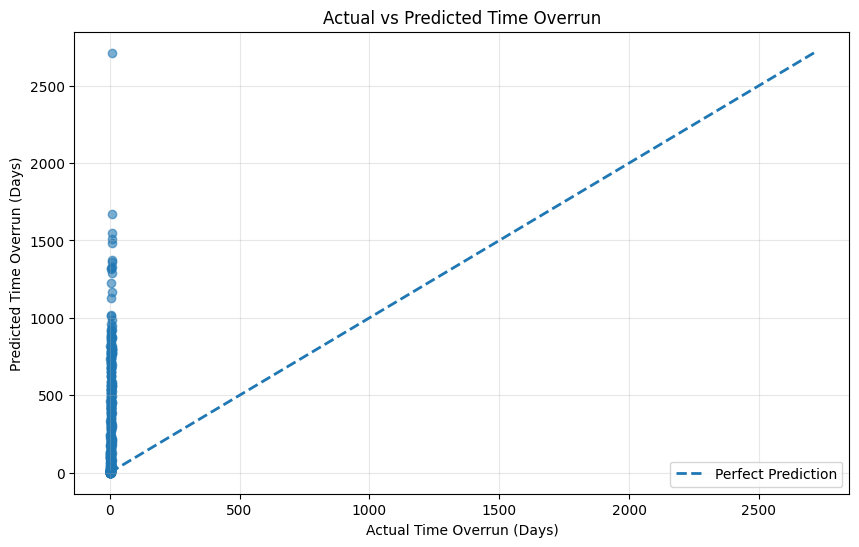

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    comparison_df["Actual_Time_Overrun_Days"],
    comparison_df["Predicted_Time_Overrun_Days"],
    alpha=0.6
)

# Perfect prediction line
max_value = max(
    comparison_df["Actual_Time_Overrun_Days"].max(),
    comparison_df["Predicted_Time_Overrun_Days"].max()
)

plt.plot(
    [0, max_value],
    [0, max_value],
    linestyle="--",
    linewidth=2,
    label="Perfect Prediction"
)

plt.xlabel("Actual Time Overrun (Days)")
plt.ylabel("Predicted Time Overrun (Days)")

plt.title(
    "Actual vs Predicted Time Overrun"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

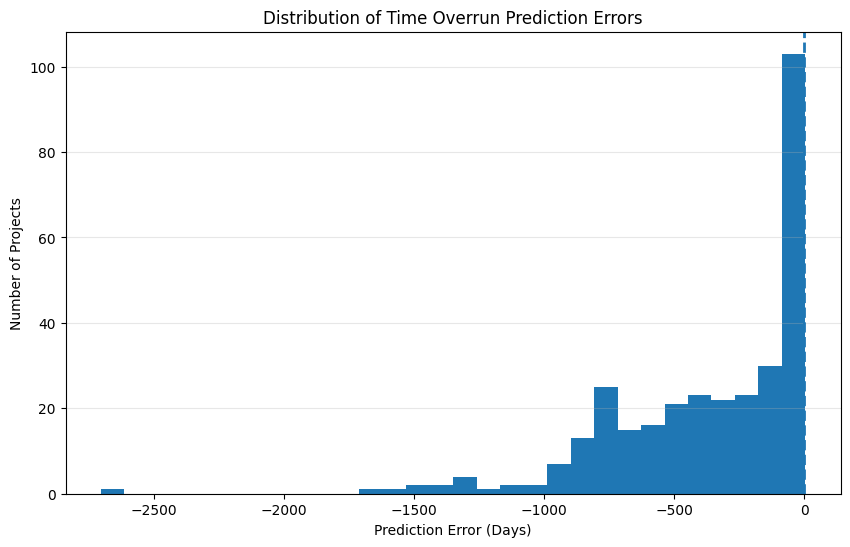

In [36]:
plt.figure(figsize=(10, 6))

plt.hist(
    comparison_df["Difference_Days"],
    bins=30
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=2
)

plt.xlabel("Prediction Error (Days)")
plt.ylabel("Number of Projects")

plt.title(
    "Distribution of Time Overrun Prediction Errors"
)

plt.grid(axis="y", alpha=0.3)

plt.show()

In [37]:
# Convert actual log target back to actual days

y_test_days = np.expm1(y_test_reg)

comparison_df = pd.DataFrame({
    "Actual_Time_Overrun_Days": y_test_days,
    "Predicted_Time_Overrun_Days": y_pred_days
})

comparison_df["Difference_Days"] = (
    comparison_df["Actual_Time_Overrun_Days"]
    - comparison_df["Predicted_Time_Overrun_Days"]
)

comparison_df.head(10)

,Actual_Time_Overrun_Days,Predicted_Time_Overrun_Days,Difference_Days
1838,1461.0,80.906905,1380.093095
1259,487.0,766.073707,-279.073707
663,365.0,156.534107,208.465893
1238,183.0,439.939784,-256.939784
1482,3621.0,989.547766,2631.452234
1302,730.0,652.538200,77.461800
1946,973.0,44.711662,928.288338
1211,487.0,108.073258,378.926742
1920,0.0,7.632954,-7.632954
810,214.0,60.166527,153.833473


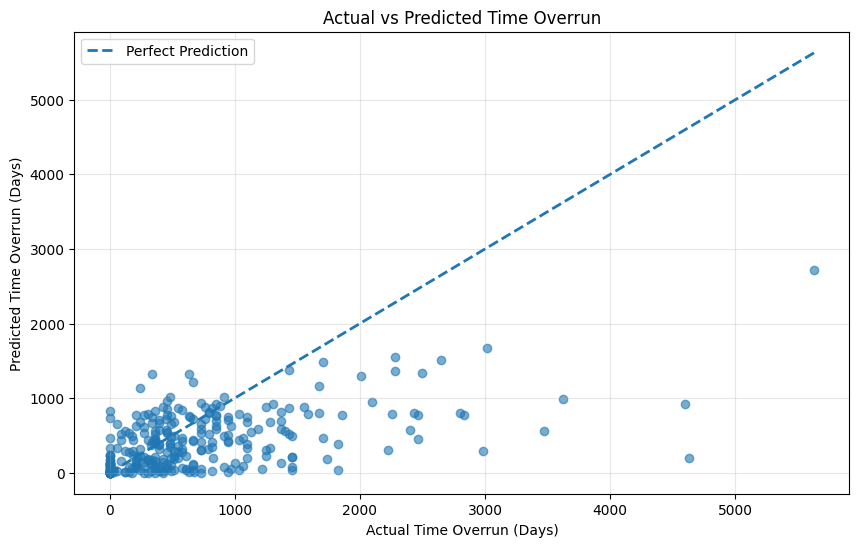

In [38]:
plt.figure(figsize=(10, 6))

plt.scatter(
    comparison_df["Actual_Time_Overrun_Days"],
    comparison_df["Predicted_Time_Overrun_Days"],
    alpha=0.6
)

# Perfect prediction line
max_value = max(
    comparison_df["Actual_Time_Overrun_Days"].max(),
    comparison_df["Predicted_Time_Overrun_Days"].max()
)

plt.plot(
    [0, max_value],
    [0, max_value],
    linestyle="--",
    linewidth=2,
    label="Perfect Prediction"
)

plt.xlabel("Actual Time Overrun (Days)")
plt.ylabel("Predicted Time Overrun (Days)")
plt.title("Actual vs Predicted Time Overrun")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

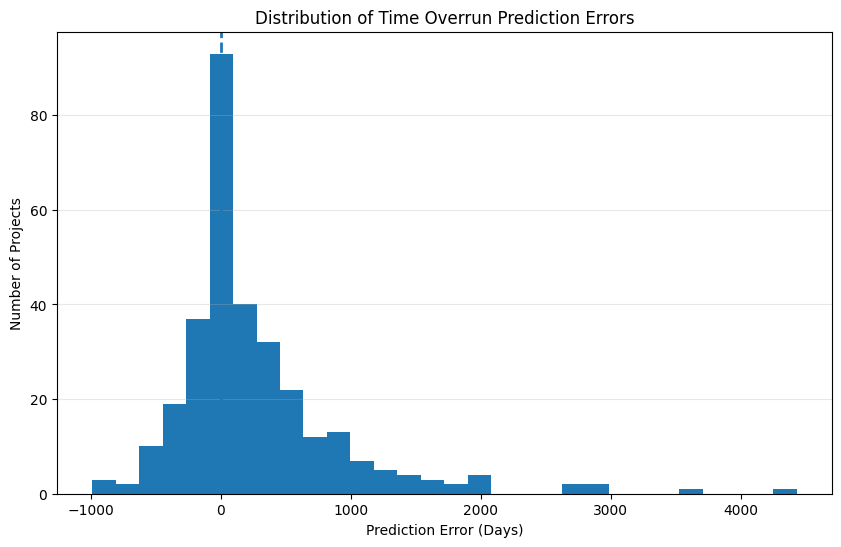

In [39]:
plt.figure(figsize=(10, 6))

plt.hist(
    comparison_df["Difference_Days"],
    bins=30
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=2
)

plt.xlabel("Prediction Error (Days)")
plt.ylabel("Number of Projects")
plt.title("Distribution of Time Overrun Prediction Errors")

plt.grid(axis="y", alpha=0.3)

plt.show()

In [40]:
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)

# Actual and predicted values are in DAYS
mae = mean_absolute_error(y_test_days,y_pred_days)

rmse = np.sqrt(
    mean_squared_error(
        y_test_days,
        y_pred_days
    )
)

r2 = r2_score(y_test_days,y_pred_days)

print("Time Overrun Regression Performance")
print("------------------------------------")

print("MAE  :", round(mae, 2), "days")
print("RMSE :", round(rmse, 2), "days")
print("R²   :", round(r2, 4))

Time Overrun Regression Performance
------------------------------------
MAE  : 416.72 days
RMSE : 710.62 days
R²   : 0.2069


In [41]:
baseline_results = {
    "Model": "Random Forest Regressor - Baseline",
    "MAE_days": round(mae, 2),
    "RMSE_days": round(rmse, 2),
    "R2": round(r2, 4)
}

baseline_results

{'Model': 'Random Forest Regressor - Baseline',
 'MAE_days': 416.72,
 'RMSE_days': np.float64(710.62),
 'R2': 0.2069}

Here Accuracy is very low, So we improve our model

In [42]:
# Convert date columns into datetime format

reg_df_clean["Start_Date"] = pd.to_datetime(
    reg_df_clean["Start_Date"],
    errors="coerce",
    dayfirst=True
)

reg_df_clean["Target_DOC"] = pd.to_datetime(
    reg_df_clean["Target_DOC"],
    errors="coerce",
    dayfirst=True
)

print(reg_df_clean[
    ["Start_Date", "Target_DOC"]
].head())

  Start_Date Target_DOC
0 2021-01-10 2025-01-10
1 2018-01-09 2021-01-09
2 2018-01-12 2021-01-12
3 2022-01-07 2024-01-06
5 2023-01-04 2026-01-12


In [43]:
# Calculate planned project duration in days

reg_df_clean["Planned_Duration_Days"] = (
    reg_df_clean["Target_DOC"]
    - reg_df_clean["Start_Date"]
).dt.days

print(
    reg_df_clean[
        [
            "Start_Date",
            "Target_DOC",
            "Planned_Duration_Days"
        ]
    ].head(10)
)

   Start_Date Target_DOC  Planned_Duration_Days
0  2021-01-10 2025-01-10                   1461
1  2018-01-09 2021-01-09                   1096
2  2018-01-12 2021-01-12                   1096
3  2022-01-07 2024-01-06                    729
5  2023-01-04 2026-01-12                   1104
6  2022-01-07 2030-01-07                   2922
7  2025-01-12 2028-01-04                   1087
9  2022-01-06 2025-01-09                   1099
10 2022-01-01 2026-01-05                   1465
12 2022-01-06 2024-01-12                    736


In [44]:
print("\nDuration Statistics:")
print(
    reg_df_clean["Planned_Duration_Days"].describe()
)

print(
    "\nNegative Duration:",
    (reg_df_clean["Planned_Duration_Days"] < 0).sum()
)


Duration Statistics:
count     1570.000000
mean      1264.913376
std       1319.098038
min       -367.000000
25%        730.000000
50%        731.000000
75%       1096.750000
max      14617.000000
Name: Planned_Duration_Days, dtype: float64

Negative Duration: 1


In [45]:
# Remove records with invalid planned duration

reg_df_clean = reg_df_clean[
    reg_df_clean["Planned_Duration_Days"] >= 0
].copy()

print("Rows after duration cleaning:", len(reg_df_clean))

print(
    "Negative durations remaining:",
    (reg_df_clean["Planned_Duration_Days"] < 0).sum()
)

Rows after duration cleaning: 1569
Negative durations remaining: 0


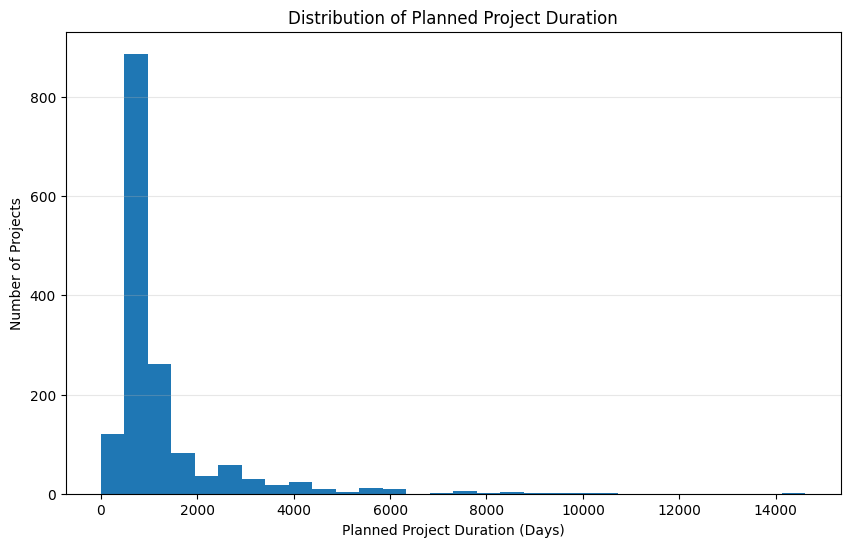

In [46]:
plt.figure(figsize=(10, 6))

plt.hist(reg_df_clean["Planned_Duration_Days"],bins=30)

plt.xlabel("Planned Project Duration (Days)")
plt.ylabel("Number of Projects")
plt.title("Distribution of Planned Project Duration")

plt.grid(axis="y", alpha=0.3)

plt.show()

CatBoost Arived

In [47]:
try:
    import catboost
    print("CatBoost version:", catboost.__version__)
except ImportError:
    print("CatBoost is not installed.")

CatBoost is not installed.


In [48]:
!pip install catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.9 MB/s eta 0:00:00


In [49]:
import catboost

print("CatBoost version:", catboost.__version__)

CatBoost version: 1.2.10


In [50]:
from catboost import CatBoostRegressor

In [51]:
catboost_reg = CatBoostRegressor(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    loss_function="RMSE",
    random_seed=42,
    verbose=0
)

print("CatBoost Regressor created successfully!")

CatBoost Regressor created successfully!


In [52]:
# Index positions of categorical columns

cat_features = [
    X_train_reg.columns.get_loc("Ministry"),
    X_train_reg.columns.get_loc("Sector"),
    X_train_reg.columns.get_loc("State")
]

print("Categorical feature indexes:")
print(cat_features)

Categorical feature indexes:
[4, 5, 6]


In [53]:
catboost_reg.fit(X_train_reg,y_train_reg,cat_features=cat_features)

# print("CatBoost Regression Model trained successfully!")

CatBoostRegressor(depth=6, iterations=500, learning_rate=0.05, loss_function='RMSE', random_seed=42, verbose=0)

In [54]:
# Predict log-transformed Time Overrun

y_pred_log_cat = catboost_reg.predict(X_test_reg)

print("First 10 Predicted Log Values:")
print(y_pred_log_cat[:10])

First 10 Predicted Log Values:
[4.72572619 6.33677587 5.52303768 6.08731335 7.20178634 6.87169412
 4.66903368 4.70386211 3.12900257 4.01546182]


In [55]:
# Convert CatBoost log predictions back to actual days

y_pred_days_cat = np.expm1(y_pred_log_cat)

print("First 10 Predicted Time Overrun Days:")
print(np.round(y_pred_days_cat[:10], 2))

First 10 Predicted Time Overrun Days:
[ 111.81  563.97  249.39  439.24 1340.83  963.58  105.59  109.37   21.85
   54.45]


In [56]:
# Convert actual log target back to days

y_test_days_cat = np.expm1(y_test_reg)

cat_comparison_df = pd.DataFrame({
    "Actual_Time_Overrun_Days": y_test_days_cat,
    "Predicted_Time_Overrun_Days": y_pred_days_cat
})

cat_comparison_df["Difference_Days"] = (
    cat_comparison_df["Actual_Time_Overrun_Days"]
    - cat_comparison_df["Predicted_Time_Overrun_Days"]
)

cat_comparison_df.head(10)

,Actual_Time_Overrun_Days,Predicted_Time_Overrun_Days,Difference_Days
1838,1461.0,111.812392,1349.187608
1259,487.0,563.971830,-76.971830
663,365.0,249.394500,115.605500
1238,183.0,439.237057,-256.237057
1482,3621.0,1340.825585,2280.174415
1302,730.0,963.581298,-233.581298
1946,973.0,105.594688,867.405312
1211,487.0,109.372621,377.627379
1920,0.0,21.851176,-21.851176
810,214.0,54.448897,159.551103


In [57]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

cat_mae = mean_absolute_error(
    y_test_days_cat,
    y_pred_days_cat
)

cat_rmse = np.sqrt(
    mean_squared_error(
        y_test_days_cat,
        y_pred_days_cat
    )
)

cat_r2 = r2_score(
    y_test_days_cat,
    y_pred_days_cat
)

print("CatBoost Time Overrun Regression Performance")
print("---------------------------------------------")

print("MAE  :", round(cat_mae, 2), "days")
print("RMSE :", round(cat_rmse, 2), "days")
print("R²   :", round(cat_r2, 4))

CatBoost Time Overrun Regression Performance
---------------------------------------------
MAE  : 411.55 days
RMSE : 708.29 days
R²   : 0.2121


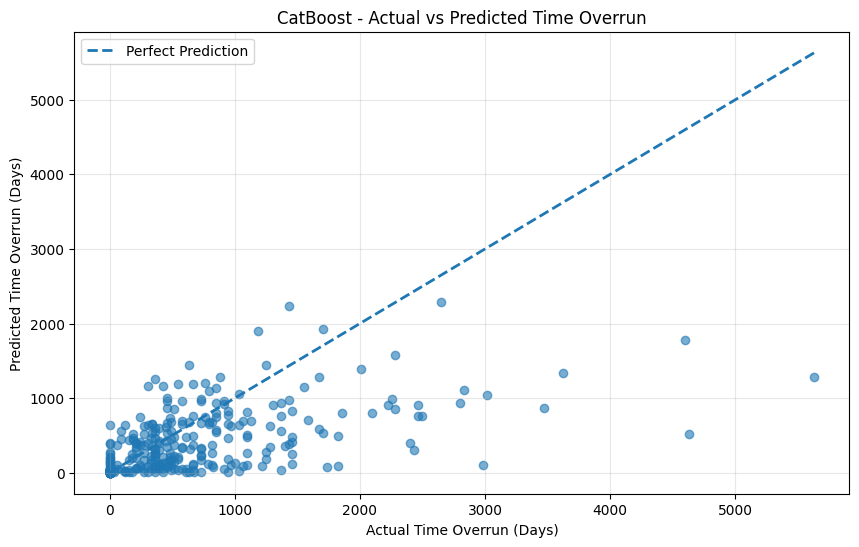

In [58]:
plt.figure(figsize=(10, 6))

plt.scatter(
    y_test_days_cat,
    y_pred_days_cat,
    alpha=0.6
)

max_value = max(
    y_test_days_cat.max(),
    y_pred_days_cat.max()
)

plt.plot(
    [0, max_value],
    [0, max_value],
    linestyle="--",
    linewidth=2,
    label="Perfect Prediction"
)

plt.xlabel("Actual Time Overrun (Days)")
plt.ylabel("Predicted Time Overrun (Days)")

plt.title(
    "CatBoost - Actual vs Predicted Time Overrun"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [59]:
# Calculate progress gap

reg_df_clean["Progress_Gap"] = (
    100 - reg_df_clean["Physical_Progress_Pct"]
)

print(
    reg_df_clean[
        [
            "Physical_Progress_Pct",
            "Progress_Gap"
        ]
    ].head(10)
)

    Physical_Progress_Pct  Progress_Gap
0                    40.0          60.0
1                    79.2          20.8
2                    95.4           4.6
3                    85.0          15.0
5                    25.0          75.0
6                    37.0          63.0
7                     0.0         100.0
9                    97.7           2.3
10                   78.0          22.0
12                   52.0          48.0


In [60]:
!pip install xgboost -q

In [61]:
import xgboost as xgb

print("XGBoost version:", xgb.__version__)

XGBoost version: 3.4.1


In [62]:
print("Cost Overrun Flag - Missing Values:")
print(df["Cost_Overrun_Flag"].isnull().sum())

print("\nCost Overrun Flag Distribution:")
print(df["Cost_Overrun_Flag"].value_counts())

Cost Overrun Flag - Missing Values:
6

Cost Overrun Flag Distribution:
Cost_Overrun_Flag
0.0    1425
1.0     535
Name: count, dtype: int64


In [63]:
cost_df = df.dropna(
    subset=["Cost_Overrun_Flag"]
).copy()

cost_df["Cost_Overrun_Flag"] = (
    cost_df["Cost_Overrun_Flag"].astype(int)
)

print("Original rows :", len(df))
print("Clean rows    :", len(cost_df))
print("Removed rows  :", len(df) - len(cost_df))

Original rows : 1966
Clean rows    : 1960
Removed rows  : 6


In [64]:
features = [
    "Original_Cost_Cr",
    "Cumulative_Expenditure_Cr",
    "Physical_Progress_Pct",
    "Expenditure_Pct_of_Original_Cost",
    "Ministry",
    "Sector",
    "State"
]

X = cost_df[features].copy()

print("Features selected:")
print(X.columns.tolist())

print("\nShape of X:", X.shape)

Features selected:
['Original_Cost_Cr', 'Cumulative_Expenditure_Cr', 'Physical_Progress_Pct', 'Expenditure_Pct_of_Original_Cost', 'Ministry', 'Sector', 'State']

Shape of X: (1960, 7)


In [65]:
y = cost_df["Cost_Overrun_Flag"]

print("Target shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

Target shape: (1960,)

Target distribution:
Cost_Overrun_Flag
0    1425
1     535
Name: count, dtype: int64


In [66]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)

print("Training data:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting data:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Training data:
X_train: (1568, 7)
y_train: (1568,)

Testing data:
X_test: (392, 7)
y_test: (392,)


In [67]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

In [68]:
numeric_features = [
    "Original_Cost_Cr",
    "Cumulative_Expenditure_Cr",
    "Physical_Progress_Pct",
    "Expenditure_Pct_of_Original_Cost"
]

categorical_features = [
    "Ministry",
    "Sector",
    "State"
]

print("Numerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['Original_Cost_Cr', 'Cumulative_Expenditure_Cr', 'Physical_Progress_Pct', 'Expenditure_Pct_of_Original_Cost']

Categorical Features:
['Ministry', 'Sector', 'State']


In [69]:
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        )
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(handle_unknown="ignore")
        )
    ]
)

In [70]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [71]:
from sklearn.linear_model import LogisticRegression

In [72]:
logistic_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

print("Logistic Regression model created!")

Logistic Regression model created!


In [73]:
logistic_model.fit(X_train,y_train)

print("Logistic Regression training completed!")

Logistic Regression training completed!


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [74]:
y_pred_lr = logistic_model.predict(X_test)

y_prob_lr = logistic_model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully!")

Predictions generated successfully!


In [75]:
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,roc_auc_score)

accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
roc_auc_lr = roc_auc_score(y_test, y_prob_lr)

print("===== Logistic Regression Results =====")
print("Accuracy :", round(accuracy_lr * 100, 2), "%")
print("Precision:", round(precision_lr * 100, 2), "%")
print("Recall   :", round(recall_lr * 100, 2), "%")
print("F1 Score :", round(f1_lr * 100, 2), "%")
print("ROC-AUC  :", round(roc_auc_lr, 4))

===== Logistic Regression Results =====
Accuracy : 75.51 %
Precision: 53.59 %
Recall   : 76.64 %
F1 Score : 63.08 %
ROC-AUC  : 0.8262


In [76]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_lr,
        target_names=[
            "No Cost Overrun",
            "Cost Overrun"
        ]
    )
)

                 precision    recall  f1-score   support

No Cost Overrun       0.90      0.75      0.82       285
   Cost Overrun       0.54      0.77      0.63       107

       accuracy                           0.76       392
      macro avg       0.72      0.76      0.72       392
   weighted avg       0.80      0.76      0.77       392



In [77]:
from sklearn.metrics import confusion_matrix

cm_lr = confusion_matrix(y_test,y_pred_lr)

print("Confusion Matrix:")
print(cm_lr)

Confusion Matrix:
[[214  71]
 [ 25  82]]


In [78]:
from sklearn.ensemble import RandomForestClassifier

In [79]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

print("Random Forest model created!")

Random Forest model created!


In [80]:
rf_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            rf_model
        )
    ]
)

print("Random Forest pipeline created!")

Random Forest pipeline created!


In [81]:
rf_pipeline.fit(
    X_train,
    y_train
)

print("Random Forest training completed!")

Random Forest training completed!


In [82]:
y_pred_rf = rf_pipeline.predict(X_test)

y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]

print("Random Forest predictions generated successfully!")

Random Forest predictions generated successfully!


In [83]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print("===== Random Forest Results =====")
print("Accuracy :", round(accuracy_rf * 100, 2), "%")
print("Precision:", round(precision_rf * 100, 2), "%")
print("Recall   :", round(recall_rf * 100, 2), "%")
print("F1 Score :", round(f1_rf * 100, 2), "%")
print("ROC-AUC  :", round(roc_auc_rf, 4))

===== Random Forest Results =====
Accuracy : 77.81 %
Precision: 57.69 %
Recall   : 70.09 %
F1 Score : 63.29 %
ROC-AUC  : 0.8437


In [84]:
print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=[
            "No Cost Overrun",
            "Cost Overrun"
        ]
    )
)

                 precision    recall  f1-score   support

No Cost Overrun       0.88      0.81      0.84       285
   Cost Overrun       0.58      0.70      0.63       107

       accuracy                           0.78       392
      macro avg       0.73      0.75      0.74       392
   weighted avg       0.80      0.78      0.78       392



In [85]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

print("Random Forest Confusion Matrix:")
print(cm_rf)

Random Forest Confusion Matrix:
[[230  55]
 [ 32  75]]


In [86]:
import xgboost as xgb

print("XGBoost version:", xgb.__version__)

XGBoost version: 3.4.1


In [87]:
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

print("XGBoost model created!")

XGBoost model created!


In [88]:
xgb_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            xgb_model
        )
    ]
)

print("XGBoost pipeline created!")

XGBoost pipeline created!


In [89]:
xgb_pipeline.fit(X_train, y_train)

print("XGBoost training completed!")

XGBoost training completed!


In [90]:
y_pred_xgb = xgb_pipeline.predict(X_test)

y_prob_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]

print("XGBoost predictions generated successfully!")

XGBoost predictions generated successfully!


In [91]:
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
roc_auc_xgb = roc_auc_score(y_test, y_prob_xgb)

print("===== XGBoost Results =====")
print("Accuracy :", round(accuracy_xgb * 100, 2), "%")
print("Precision:", round(precision_xgb * 100, 2), "%")
print("Recall   :", round(recall_xgb * 100, 2), "%")
print("F1 Score :", round(f1_xgb * 100, 2), "%")
print("ROC-AUC  :", round(roc_auc_xgb, 4))

===== XGBoost Results =====
Accuracy : 82.4 %
Precision: 72.62 %
Recall   : 57.01 %
F1 Score : 63.87 %
ROC-AUC  : 0.8541


In [92]:
print(
    classification_report(
        y_test,
        y_pred_xgb,
        target_names=[
            "No Cost Overrun",
            "Cost Overrun"
        ]
    )
)

                 precision    recall  f1-score   support

No Cost Overrun       0.85      0.92      0.88       285
   Cost Overrun       0.73      0.57      0.64       107

       accuracy                           0.82       392
      macro avg       0.79      0.74      0.76       392
   weighted avg       0.82      0.82      0.82       392



In [93]:
cm_xgb = confusion_matrix(
    y_test,
    y_pred_xgb
)

print("XGBoost Confusion Matrix:")
print(cm_xgb)

XGBoost Confusion Matrix:
[[262  23]
 [ 46  61]]


In [94]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy": [
        accuracy_lr * 100,
        accuracy_rf * 100,
        accuracy_xgb * 100
    ],

    "Precision": [
        precision_lr * 100,
        precision_rf * 100,
        precision_xgb * 100
    ],

    "Recall": [
        recall_lr * 100,
        recall_rf * 100,
        recall_xgb * 100
    ],

    "F1 Score": [
        f1_lr * 100,
        f1_rf * 100,
        f1_xgb * 100
    ],

    "ROC-AUC": [
        roc_auc_lr,
        roc_auc_rf,
        roc_auc_xgb
    ]
})

comparison.round(2)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,75.51,53.59,76.64,63.08,0.83
1,Random Forest,77.81,57.69,70.09,63.29,0.84
2,XGBoost,82.40,72.62,57.01,63.87,0.85


In [95]:
best_model = comparison.loc[
    comparison["ROC-AUC"].idxmax()
]

print("Best Model:")
print(best_model)

Best Model:
Model          XGBoost
Accuracy     82.397959
Precision    72.619048
Recall       57.009346
F1 Score     63.874346
ROC-AUC       0.854107
Name: 2, dtype: object


In [96]:
cm_xgb = confusion_matrix(y_test,y_pred_xgb)

print("XGBoost Confusion Matrix:")
print(cm_xgb)

XGBoost Confusion Matrix:
[[262  23]
 [ 46  61]]


In [97]:
print(classification_report(y_test,y_pred_xgb,
        target_names=[
            "No Cost Overrun",
            "Cost Overrun"
        ]
    )
)

                 precision    recall  f1-score   support

No Cost Overrun       0.85      0.92      0.88       285
   Cost Overrun       0.73      0.57      0.64       107

       accuracy                           0.82       392
      macro avg       0.79      0.74      0.76       392
   weighted avg       0.82      0.82      0.82       392



In [98]:
threshold = 0.40

y_pred_xgb_40 = (y_prob_xgb >= threshold).astype(int)

print("Threshold:", threshold)
print(classification_report(y_test,y_pred_xgb_40,
        target_names=[
            "No Cost Overrun",
            "Cost Overrun"
        ]
    )
)

Threshold: 0.4
                 precision    recall  f1-score   support

No Cost Overrun       0.87      0.89      0.88       285
   Cost Overrun       0.70      0.65      0.68       107

       accuracy                           0.83       392
      macro avg       0.79      0.77      0.78       392
   weighted avg       0.83      0.83      0.83       392



In [99]:
cm_xgb_40 = confusion_matrix(y_test,y_pred_xgb_40)

print("Confusion Matrix:")
print(cm_xgb_40)

Confusion Matrix:
[[255  30]
 [ 37  70]]


In [100]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

thresholds = [0.30, 0.40, 0.50, 0.60, 0.70]

threshold_results = []

for threshold in thresholds:

    y_pred = (y_prob_xgb >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test, y_pred) * 100,
        "Precision": precision_score(y_test, y_pred) * 100,
        "Recall": recall_score(y_test, y_pred) * 100,
        "F1_Score": f1_score(y_test, y_pred) * 100
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df.round(2)

,Threshold,Accuracy,Precision,Recall,F1_Score
0,0.3,79.34,60.83,68.22,64.32
1,0.4,82.91,70.00,65.42,67.63
2,0.5,82.40,72.62,57.01,63.87
3,0.6,80.87,72.22,48.60,58.10
4,0.7,79.85,75.93,38.32,50.93


In [101]:
print("Cost Overrun (₹ Crore) - Missing Values:")
print(cost_df["Cost_Overrun_Cr"].isnull().sum())

print("\nCost Overrun (₹ Crore) - Valid Values:")
print(cost_df["Cost_Overrun_Cr"].notnull().sum())

print("\nBasic Statistics:")
print(cost_df["Cost_Overrun_Cr"].describe())

Cost Overrun (₹ Crore) - Missing Values:
0

Cost Overrun (₹ Crore) - Valid Values:
1960

Basic Statistics:
count      1960.000000
mean        279.072352
std        3681.625318
min      -10923.200000
25%           0.000000
50%           0.000000
75%          11.972500
max      126891.000000
Name: Cost_Overrun_Cr, dtype: float64


In [102]:
negative_cost = cost_df[
    cost_df["Cost_Overrun_Cr"] < 0
]

print("Negative Cost Overrun Records:",
      len(negative_cost))

print("\nNegative Cost Overrun values:")

print(
    negative_cost[
        [
            "Project_ID",
            "Project_Name",
            "Original_Cost_Cr",
            "Revised_Cost_Cr",
            "Cost_Overrun_Cr",
            "Cost_Overrun_Pct"
        ]
    ].sort_values(
        "Cost_Overrun_Cr"
    ).head(20)
)

Negative Cost Overrun Records: 339

Negative Cost Overrun values:
     Project_ID                                       Project_Name  \
3        400013  Saturation 4G mobile coverage of Uncovered Vil...   
1664     701593  4G Services by BSNL (Department of Telecommuni...   
1199     618738  6L Bridge and its approaches across River Gang...   
60       400185  GOPALJI KANIHA OCP [10 TO 30 M (MCL - CIL) (40...   
1668     701602  Provision of 4G based mobile services in 7,287...   
126      604859  Integrated Para Xylene [PX] and Purified Terep...   
1000     618514  6L of Kagal-Satara section from Km 658.000 to ...   
1358     618914  4L Elevated Corridor and at-grade improvements...   
1046     618564  6L with PS of Samakhiyali to Santalpur section...   
1233     618777  4L of Pileru to Kalur Section from Km 55.900 t...   
1235     618779  4L of Aurangabad-Paithan (NHAI) (618779) (N240...   
1523     619144  Hospet - Chitradurga from km. 299.00 to km. 41...   
1632     701329  Petroch

In [103]:
# Keep only projects where actual cost overrun is positive

cost_reg_df = cost_df[cost_df["Cost_Overrun_Cr"] > 0].copy()

print("Total Cost Dataset :", len(cost_df))
print("Positive Overrun Projects :", len(cost_reg_df))
print("Removed No-Overrun/Underrun Projects :",
      len(cost_df) - len(cost_reg_df))

Total Cost Dataset : 1960
Positive Overrun Projects : 535
Removed No-Overrun/Underrun Projects : 1425


In [104]:
print("Cost Overrun Statistics:")
print(cost_reg_df["Cost_Overrun_Cr"].describe())

Cost Overrun Statistics:
count       535.000000
mean       1202.620336
std        6933.584187
min           0.010000
25%          52.130000
50%         231.580000
75%         666.370000
max      126891.000000
Name: Cost_Overrun_Cr, dtype: float64


In [105]:
print("Highest Cost Overrun Projects:")

print(
    cost_reg_df[
        [
            "Project_ID",
            "Project_Name",
            "Original_Cost_Cr",
            "Revised_Cost_Cr",
            "Cost_Overrun_Cr",
            "Cost_Overrun_Pct"
        ]
    ]
    .sort_values(
        "Cost_Overrun_Cr",
        ascending=False
    )
    .head(10)
)

Highest Cost Overrun Projects:
     Project_ID                                       Project_Name  \
1836     706775  BharatNet (Department of Telecommunications [D...   
1708     705237  Western Dedicated Freight Corridor (DFCCIL) (7...   
1659     701415  Polavaram Irrigation Project (Water Resources-...   
1629     701263  Rajasthan Refinery Project (MinistryofPetroleu...   
99       602096  Subansiri Lower HE Project [2000 MW] (National...   
1684     702637  Mumbai Metro Line 3 (Mumbai Metro Rail Corpora...   
121      604791  Numaligarh Refinery Expansion Project (Ministr...   
1640     701372  Sardar Sarovar Project (Narmada and Water Reso...   
105      602185  Tapovan-Vishnugad HEP [4x130 MW] (National The...   
1724     705391  Jiribam-Imphal new line project (Northeast Fro...   

      Original_Cost_Cr  Revised_Cost_Cr  Cost_Overrun_Cr  Cost_Overrun_Pct  
1836          61109.00         188000.0        126891.00          207.6470  
1708          51101.00         124005.0     

In [106]:
Q1 = cost_reg_df["Cost_Overrun_Cr"].quantile(0.25)
Q3 = cost_reg_df["Cost_Overrun_Cr"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = cost_reg_df[
    (cost_reg_df["Cost_Overrun_Cr"] < lower_bound) |
    (cost_reg_df["Cost_Overrun_Cr"] > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of Outliers:", len(outliers))

Q1: 52.129999999999995
Q3: 666.37
IQR: 614.24
Lower Bound: -869.23
Upper Bound: 1587.73
Number of Outliers: 57


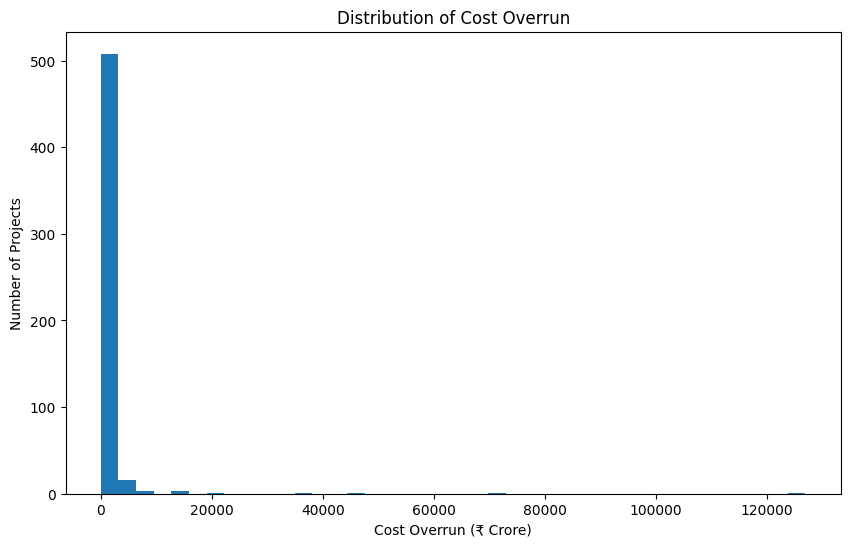

In [107]:
plt.figure(figsize=(10, 6))

plt.hist(cost_reg_df["Cost_Overrun_Cr"],bins=40)

plt.xlabel("Cost Overrun (₹ Crore)")
plt.ylabel("Number of Projects")
plt.title("Distribution of Cost Overrun")

plt.show()

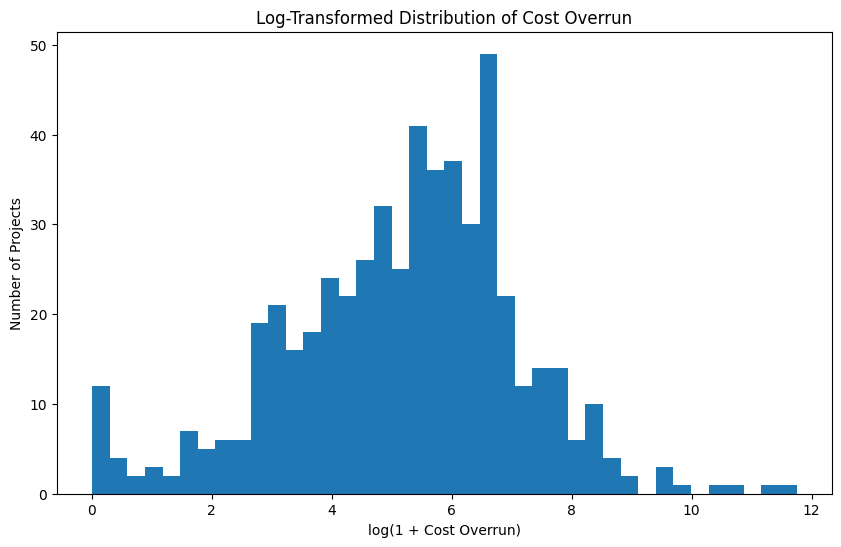

In [108]:
plt.figure(figsize=(10, 6))

plt.hist(np.log1p(cost_reg_df["Cost_Overrun_Cr"]),bins=40)

plt.xlabel("log(1 + Cost Overrun)")
plt.ylabel("Number of Projects")
plt.title("Log-Transformed Distribution of Cost Overrun")

plt.show()

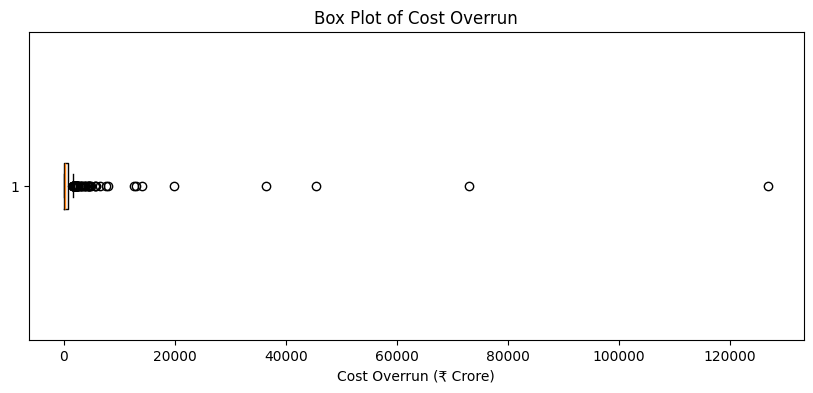

In [109]:
plt.figure(figsize=(10, 4))

plt.boxplot(cost_reg_df["Cost_Overrun_Cr"],vert=False)

plt.xlabel("Cost Overrun (₹ Crore)")
plt.title("Box Plot of Cost Overrun")

plt.show()

In [110]:
cost_reg_df["Log_Cost_Overrun"] = np.log1p(
    cost_reg_df["Cost_Overrun_Cr"]
)

cost_reg_df[
    [
        "Cost_Overrun_Cr",
        "Log_Cost_Overrun"
    ]
].head(10)

,Cost_Overrun_Cr,Log_Cost_Overrun
1,160.00,5.081404
5,678.07,6.520724
19,461.98,6.137684
20,670.19,6.509052
21,299.98,5.707044
22,213.74,5.369428
23,4608.79,8.435938
24,267.07,5.591248
25,142.32,4.965080
26,170.55,5.144875


In [111]:
reg_features = [
    "Original_Cost_Cr",
    "Cumulative_Expenditure_Cr",
    "Physical_Progress_Pct",
    "Expenditure_Pct_of_Original_Cost",
    "Ministry",
    "Sector",
    "State"
]

X_reg = cost_reg_df[reg_features].copy()

print("Regression Features:")
print(X_reg.columns.tolist())

print("\nShape of X_reg:", X_reg.shape)

Regression Features:
['Original_Cost_Cr', 'Cumulative_Expenditure_Cr', 'Physical_Progress_Pct', 'Expenditure_Pct_of_Original_Cost', 'Ministry', 'Sector', 'State']

Shape of X_reg: (535, 7)


In [112]:
y_reg = cost_reg_df["Log_Cost_Overrun"]

print("Target Shape:", y_reg.shape)

print("\nTarget Statistics:")
print(y_reg.describe())

Target Shape: (535,)

Target Statistics:
count    535.000000
mean       5.185819
std        1.950750
min        0.009950
25%        3.972717
50%        5.449234
75%        6.503343
max       11.751092
Name: Log_Cost_Overrun, dtype: float64


In [113]:
from sklearn.model_selection import train_test_split

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(X_reg,y_reg,test_size=0.20,random_state=42)

print("Training data:")
print("X_reg_train:", X_reg_train.shape)
print("y_reg_train:", y_reg_train.shape)

print("\nTesting data:")
print("X_reg_test:", X_reg_test.shape)
print("y_reg_test:", y_reg_test.shape)

Training data:
X_reg_train: (428, 7)
y_reg_train: (428,)

Testing data:
X_reg_test: (107, 7)
y_reg_test: (107,)


In [114]:
numeric_reg_features = [
    "Original_Cost_Cr",
    "Cumulative_Expenditure_Cr",
    "Physical_Progress_Pct",
    "Expenditure_Pct_of_Original_Cost"
]

categorical_reg_features = [
    "Ministry",
    "Sector",
    "State"
]

print("Numeric features:", numeric_reg_features)
print("Categorical features:", categorical_reg_features)

Numeric features: ['Original_Cost_Cr', 'Cumulative_Expenditure_Cr', 'Physical_Progress_Pct', 'Expenditure_Pct_of_Original_Cost']
Categorical features: ['Ministry', 'Sector', 'State']


In [115]:
numeric_reg_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        )
    ]
)

categorical_reg_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(handle_unknown="ignore")
        )
    ]
)

reg_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_reg_transformer,
            numeric_reg_features
        ),
        (
            "cat",
            categorical_reg_transformer,
            categorical_reg_features
        )
    ]
)

print("Regression preprocessing pipeline created!")

Regression preprocessing pipeline created!


In [116]:
from sklearn.linear_model import LinearRegression

In [117]:
linear_reg_model = Pipeline(
    steps=[
        (
            "preprocessor",
            reg_preprocessor
        ),
        (
            "regressor",
            LinearRegression()
        )
    ]
)

print("Linear Regression model created!")

Linear Regression model created!


In [118]:
linear_reg_model.fit(X_reg_train,y_reg_train)

print("Linear Regression training completed!")

Linear Regression training completed!


In [119]:
y_pred_log_lr = linear_reg_model.predict(X_reg_test)

print("First 10 predicted log values:")
print(y_pred_log_lr[:10])

First 10 predicted log values:
[4.96490519 4.94087309 4.58484889 4.75063447 4.50567752 5.58975125
 7.66349694 5.83822667 5.31300797 6.60337047]


In [120]:
y_pred_cost_lr = np.expm1(y_pred_log_lr)

y_actual_cost = np.expm1(y_reg_test)

print("First 10 predicted Cost Overrun (₹ Cr):")
print(y_pred_cost_lr[:10])

First 10 predicted Cost Overrun (₹ Cr):
[ 142.2949637   138.89233451   96.98837878  114.65764242   89.52965924
  266.66902938 2128.1900744   342.17024653  201.95980821  736.57698429]


In [121]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_lr = mean_absolute_error(y_actual_cost,y_pred_cost_lr)

rmse_lr = np.sqrt(mean_squared_error(y_actual_cost,y_pred_cost_lr))

r2_lr = r2_score(y_actual_cost,y_pred_cost_lr)

print("===== Linear Regression Results =====")
print("MAE :", round(mae_lr, 2), "Crore")
print("RMSE:", round(rmse_lr, 2), "Crore")
print("R²  :", round(r2_lr, 4))

===== Linear Regression Results =====
MAE : 4355.12 Crore
RMSE: 25207.41 Crore
R²  : -2.7653


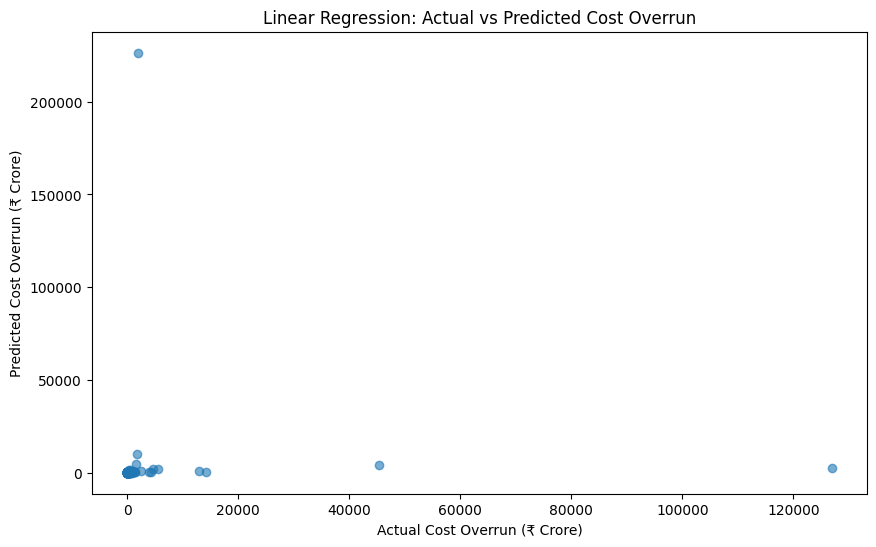

In [122]:
plt.figure(figsize=(10, 6))

plt.scatter(y_actual_cost,y_pred_cost_lr,alpha=0.6)

plt.xlabel("Actual Cost Overrun (₹ Crore)")
plt.ylabel("Predicted Cost Overrun (₹ Crore)")
plt.title("Linear Regression: Actual vs Predicted Cost Overrun")

plt.show()

In [123]:
rf_reg_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

print("Random Forest Regressor created!")

Random Forest Regressor created!


In [124]:
rf_reg_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            reg_preprocessor
        ),
        (
            "regressor",
            rf_reg_model
        )
    ]
)

print("Random Forest Regression pipeline created!")

Random Forest Regression pipeline created!


In [125]:
rf_reg_pipeline.fit(X_reg_train,y_reg_train)

print("Random Forest Regressor training completed!")

Random Forest Regressor training completed!


In [126]:
y_pred_log_rf = rf_reg_pipeline.predict(X_reg_test)

print("First 10 predicted log values:")
print(y_pred_log_rf[:10])

First 10 predicted log values:
[4.6358124  5.72149038 5.34784396 5.08739256 3.15233718 5.61370458
 7.81814455 6.48729901 5.65662222 6.64295634]


In [127]:
y_pred_cost_rf = np.expm1(y_pred_log_rf)

print("First 10 predicted Cost Overrun (₹ Cr):")
print(y_pred_cost_rf[:10])

First 10 predicted Cost Overrun (₹ Cr):
[ 102.11165215  304.35968708  209.15470712  160.96699097   22.39066894
  273.15800061 2484.28980385  655.7470965   285.18035318  766.36022078]


In [128]:
mae_rf = mean_absolute_error(y_actual_cost,y_pred_cost_rf)

rmse_rf = np.sqrt(mean_squared_error(y_actual_cost,y_pred_cost_rf))

r2_rf = r2_score(y_actual_cost,y_pred_cost_rf)

print("===== Random Forest Regressor Results =====")
print("MAE :", round(mae_rf, 2), "Crore")
print("RMSE:", round(rmse_rf, 2), "Crore")
print("R²  :", round(r2_rf, 4))

===== Random Forest Regressor Results =====
MAE : 2047.36 Crore
RMSE: 12738.27 Crore
R²  : 0.0385


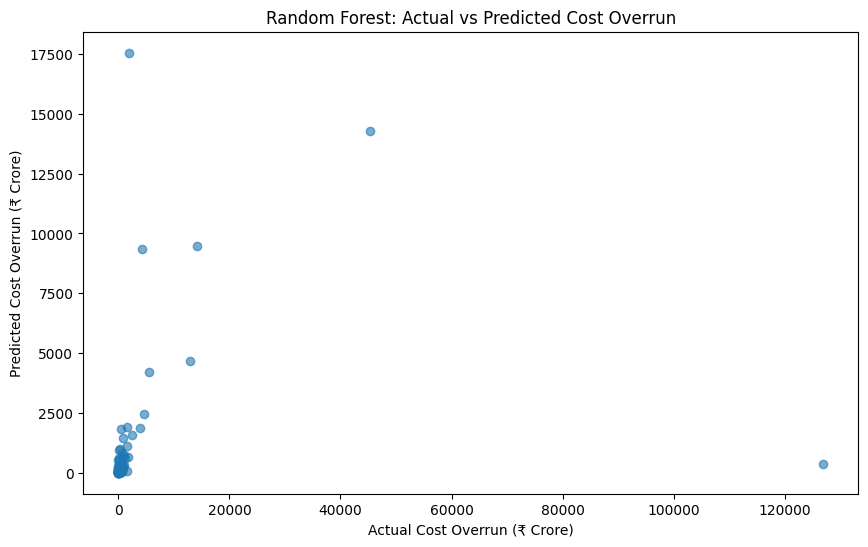

In [129]:
plt.figure(figsize=(10, 6))

plt.scatter(
    y_actual_cost,
    y_pred_cost_rf,
    alpha=0.6
)

plt.xlabel("Actual Cost Overrun (₹ Crore)")
plt.ylabel("Predicted Cost Overrun (₹ Crore)")
plt.title("Random Forest: Actual vs Predicted Cost Overrun")

plt.show()

In [130]:
from xgboost import XGBRegressor

print("XGBoost Regressor imported successfully!")

XGBoost Regressor imported successfully!


In [131]:
xgb_reg_model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

print("XGBoost Regressor created successfully!")

XGBoost Regressor created successfully!


In [132]:
xgb_reg_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            reg_preprocessor
        ),
        (
            "regressor",
            xgb_reg_model
        )
    ]
)

print("XGBoost Regression Pipeline created successfully!")

XGBoost Regression Pipeline created successfully!


In [133]:
xgb_reg_pipeline.fit(X_reg_train,y_reg_train)

print("XGBoost Regressor training completed!")

XGBoost Regressor training completed!


In [134]:
y_pred_log_xgb = xgb_reg_pipeline.predict(X_reg_test)

print("First 10 predicted log values:")
print(y_pred_log_xgb[:10])

First 10 predicted log values:
[5.3788033 6.4283366 4.289783  4.141336  4.271836  5.809166  7.837489
 6.3573747 5.873484  7.077655 ]


In [135]:
y_pred_cost_xgb = np.expm1(y_pred_log_xgb)

print("First 10 predicted Cost Overrun (₹ Cr):")
print(y_pred_cost_xgb[:10])

First 10 predicted Cost Overrun (₹ Cr):
[ 215.76271  618.14325   71.95064   61.88678   70.65305  332.341
 2532.8347   575.7303   354.48538 1184.1858 ]


In [136]:
mae_xgb = mean_absolute_error(y_actual_cost,y_pred_cost_xgb)

rmse_xgb = np.sqrt(mean_squared_error(y_actual_cost,y_pred_cost_xgb))

r2_xgb = r2_score(y_actual_cost,y_pred_cost_xgb)

print("===== XGBoost Regressor Results =====")
print("MAE :", round(mae_xgb, 2), "Crore")
print("RMSE:", round(rmse_xgb, 2), "Crore")
print("R²  :", round(r2_xgb, 4))

===== XGBoost Regressor Results =====
MAE : 2041.97 Crore
RMSE: 12779.4 Crore
R²  : 0.0323


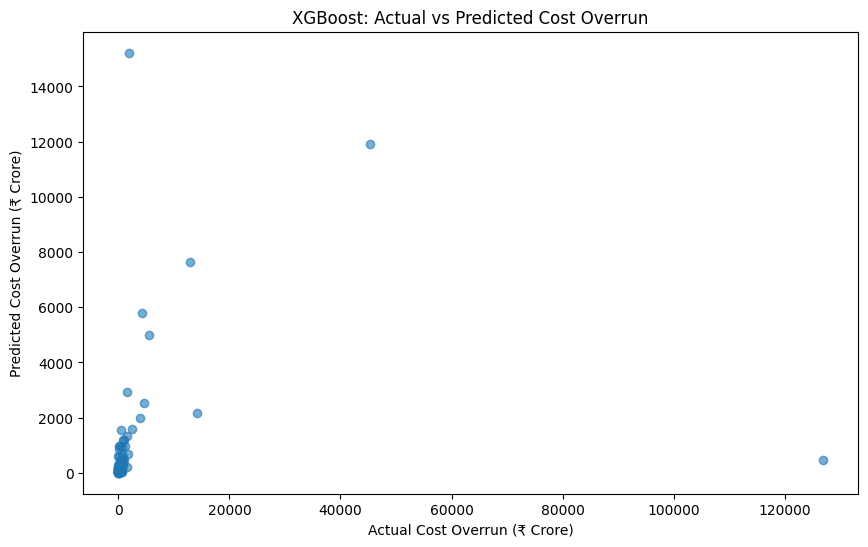

In [137]:
plt.figure(figsize=(10, 6))

plt.scatter(
    y_actual_cost,
    y_pred_cost_xgb,
    alpha=0.6
)

plt.xlabel("Actual Cost Overrun (₹ Crore)")
plt.ylabel("Predicted Cost Overrun (₹ Crore)")
plt.title("XGBoost: Actual vs Predicted Cost Overrun")

plt.show()

In [138]:
reg_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        mae_lr,
        mae_rf,
        mae_xgb
    ],
    "RMSE": [
        rmse_lr,
        rmse_rf,
        rmse_xgb
    ],
    "R2": [
        r2_lr,
        r2_rf,
        r2_xgb
    ]
})

reg_comparison.round(2)

,Model,MAE,RMSE,R2
0,Linear Regression,4355.12,25207.41,-2.77
1,Random Forest,2047.36,12738.27,0.04
2,XGBoost,2041.97,12779.40,0.03


In [139]:
mae_log_xgb = mean_absolute_error(
    y_reg_test,
    y_pred_log_xgb
)

rmse_log_xgb = np.sqrt(
    mean_squared_error(
        y_reg_test,
        y_pred_log_xgb
    )
)

r2_log_xgb = r2_score(
    y_reg_test,
    y_pred_log_xgb
)

print("===== XGBoost Log-Scale Results =====")
print("MAE :", round(mae_log_xgb, 4))
print("RMSE:", round(rmse_log_xgb, 4))
print("R²  :", round(r2_log_xgb, 4))

===== XGBoost Log-Scale Results =====
MAE : 1.164
RMSE: 1.6783
R²  : 0.383


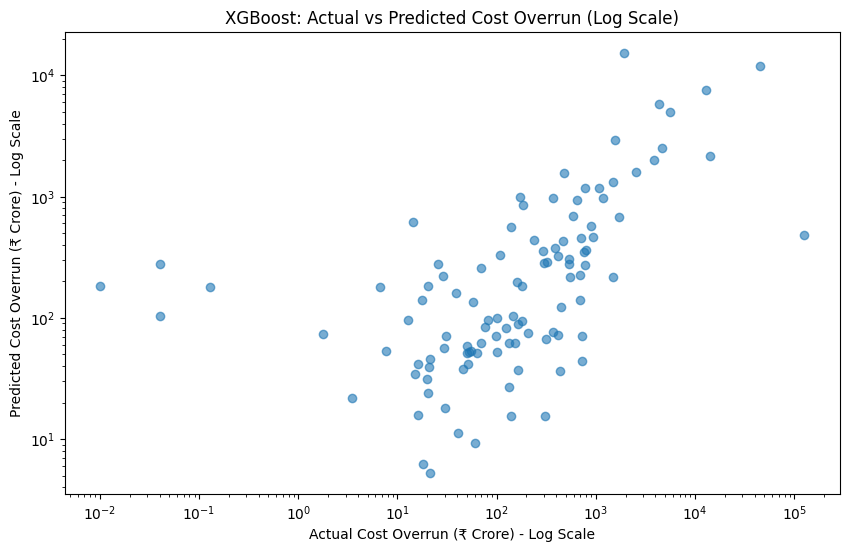

In [140]:
plt.figure(figsize=(10, 6))

plt.scatter(
    y_actual_cost,
    y_pred_cost_xgb,
    alpha=0.6
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Actual Cost Overrun (₹ Crore) - Log Scale")
plt.ylabel("Predicted Cost Overrun (₹ Crore) - Log Scale")
plt.title("XGBoost: Actual vs Predicted Cost Overrun (Log Scale)")

plt.show()

In [141]:
y_pred_log_rf = rf_reg_pipeline.predict(X_reg_test)

mae_log_rf = mean_absolute_error(
    y_reg_test,
    y_pred_log_rf
)

rmse_log_rf = np.sqrt(
    mean_squared_error(
        y_reg_test,
        y_pred_log_rf
    )
)

r2_log_rf = r2_score(
    y_reg_test,
    y_pred_log_rf
)

print("===== Random Forest Log-Scale Results =====")
print("MAE :", round(mae_log_rf, 4))
print("RMSE:", round(rmse_log_rf, 4))
print("R²  :", round(r2_log_rf, 4))

===== Random Forest Log-Scale Results =====
MAE : 1.1384
RMSE: 1.6373
R²  : 0.4127


In [142]:
print("Cost Overrun Percentage Statistics:")
print(cost_df["Cost_Overrun_Pct"].describe())

Cost Overrun Percentage Statistics:
count    1960.000000
mean        8.507390
std        50.819456
min       -99.958100
25%         0.000000
50%         0.000000
75%         1.211875
max      1231.528000
Name: Cost_Overrun_Pct, dtype: float64


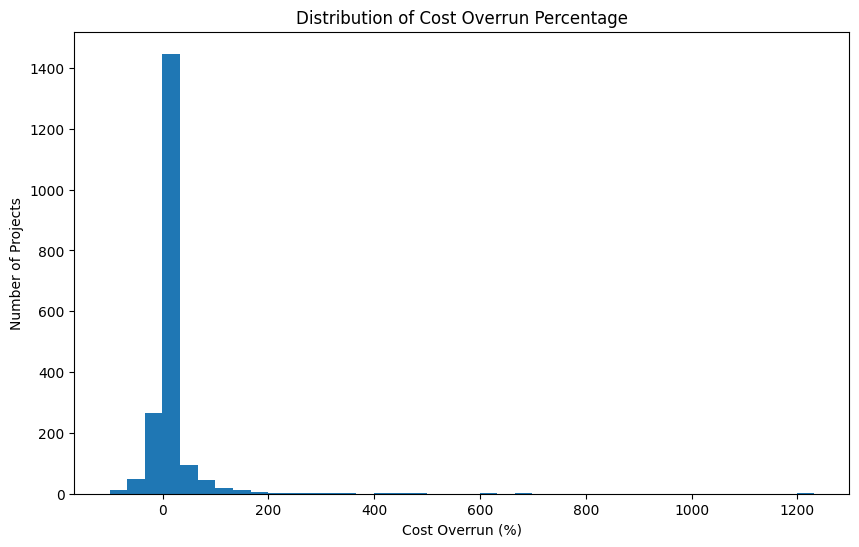

In [143]:
plt.figure(figsize=(10, 6))

plt.hist(cost_df["Cost_Overrun_Pct"].dropna(),bins=40)

plt.xlabel("Cost Overrun (%)")
plt.ylabel("Number of Projects")
plt.title("Distribution of Cost Overrun Percentage")

plt.show()

In [144]:
print("Negative Cost Overrun Percentage:",
      (cost_df["Cost_Overrun_Pct"] < 0).sum())

print("Zero Cost Overrun Percentage:",
      (cost_df["Cost_Overrun_Pct"] == 0).sum())

print("Positive Cost Overrun Percentage:",
      (cost_df["Cost_Overrun_Pct"] > 0).sum())

Negative Cost Overrun Percentage: 339
Zero Cost Overrun Percentage: 1087
Positive Cost Overrun Percentage: 534


In [145]:
error_df = pd.DataFrame({
    "Actual_Cost_Overrun": y_actual_cost,
    "Predicted_Cost_Overrun": y_pred_cost_rf
})

error_df["Absolute_Error"] = (
    abs(
        error_df["Actual_Cost_Overrun"]
        - error_df["Predicted_Cost_Overrun"]
    )
)

error_df.head(10)

,Actual_Cost_Overrun,Predicted_Cost_Overrun,Absolute_Error
951,1482.64,102.111652,1380.528348
974,14.50,304.359687,289.859687
1035,412.55,209.154707,203.395293
1281,134.22,160.966991,26.746991
563,99.68,22.390669,77.289331
1514,107.46,273.158001,165.698001
23,4608.79,2484.289804,2124.500196
1777,901.00,655.747096,245.252904
1116,292.51,285.180353,7.329647
162,1072.44,766.360221,306.079779


In [146]:
print("Lowest Errors:")
print(
    error_df.sort_values(
        "Absolute_Error"
    ).head(10)
)

print("\nHighest Errors:")
print(
    error_df.sort_values(
        "Absolute_Error",
        ascending=False
    ).head(10)
)

Lowest Errors:
      Actual_Cost_Overrun  Predicted_Cost_Overrun  Absolute_Error
1907                82.56               79.837615        2.722385
521                 21.10               24.087557        2.987557
491                 20.14               23.406228        3.266228
1264                16.08               19.453027        3.373027
1727                18.00               22.112987        4.112987
1116               292.51              285.180353        7.329647
1776               102.00               92.418111        9.581889
1462                63.79               54.111064        9.678936
1879                49.75               60.100928       10.350928
1                  160.00              171.950213       11.950213

Highest Errors:
      Actual_Cost_Overrun  Predicted_Cost_Overrun  Absolute_Error
1836            126891.00              361.499992   126529.500008
1659             45397.86            14261.839031    31136.020969
1631              1914.00            17542.6

In [147]:
prediction_output = pd.DataFrame({
    "Actual_Cost_Overrun": y_actual_cost,
    "Predicted_Cost_Overrun": y_pred_cost_rf
})

prediction_output["Expected_Revised_Cost"] = (
    X_reg_test["Original_Cost_Cr"].values
    + prediction_output["Predicted_Cost_Overrun"]
)

prediction_output.head(10)

,Actual_Cost_Overrun,Predicted_Cost_Overrun,Expected_Revised_Cost
951,1482.64,102.111652,1426.951652
974,14.50,304.359687,2064.179687
1035,412.55,209.154707,1963.994707
1281,134.22,160.966991,1678.836991
563,99.68,22.390669,201.240669
1514,107.46,273.158001,2083.198001
23,4608.79,2484.289804,3815.589804
1777,901.00,655.747096,4715.747096
1116,292.51,285.180353,2553.170353
162,1072.44,766.360221,2225.360221


In [148]:
error_df["Percentage_Error"] = (
    abs(
        error_df["Actual_Cost_Overrun"]
        - error_df["Predicted_Cost_Overrun"]
    )
    / error_df["Actual_Cost_Overrun"]
) * 100

error_df.head(10)

,Actual_Cost_Overrun,Predicted_Cost_Overrun,Absolute_Error,Percentage_Error
951,1482.64,102.111652,1380.528348,93.112849
974,14.50,304.359687,289.859687,1999.032325
1035,412.55,209.154707,203.395293,49.301974
1281,134.22,160.966991,26.746991,19.927724
563,99.68,22.390669,77.289331,77.537451
1514,107.46,273.158001,165.698001,154.195050
23,4608.79,2484.289804,2124.500196,46.096702
1777,901.00,655.747096,245.252904,27.220078
1116,292.51,285.180353,7.329647,2.505776
162,1072.44,766.360221,306.079779,28.540504


In [149]:
print("Mean Percentage Error:",
      round(error_df["Percentage_Error"].mean(), 2), "%")

print("Median Percentage Error:",
      round(error_df["Percentage_Error"].median(), 2), "%")

Mean Percentage Error: 29550.45 %
Median Percentage Error: 64.19 %


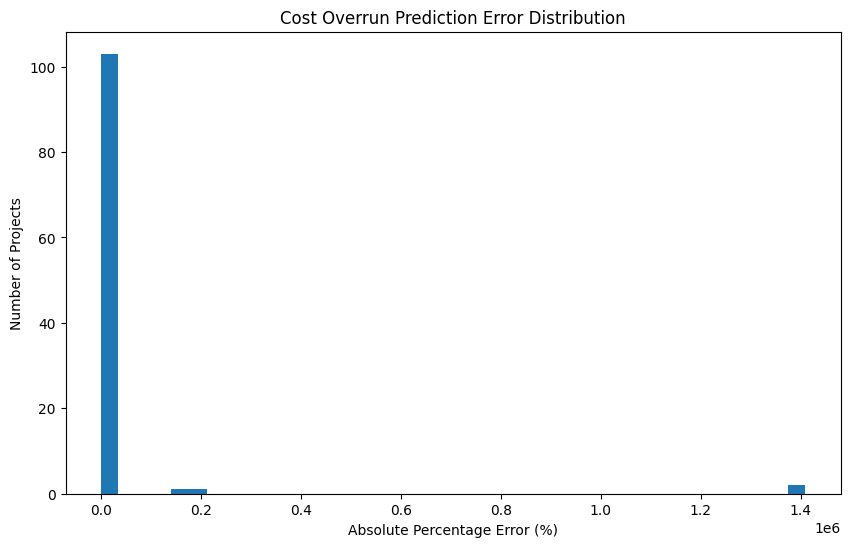

In [150]:
plt.figure(figsize=(10, 6))

plt.hist(
    error_df["Percentage_Error"].replace(
        [np.inf, -np.inf],
        np.nan
    ).dropna(),
    bins=40
)

plt.xlabel("Absolute Percentage Error (%)")
plt.ylabel("Number of Projects")
plt.title("Cost Overrun Prediction Error Distribution")

plt.show()

In [151]:
from sklearn.metrics import median_absolute_error

median_percentage_error = (
    np.median(error_df["Percentage_Error"].replace(
        [np.inf, -np.inf],
        np.nan
    ).dropna())
)

print(
    "Median Absolute Percentage Error:",
    round(median_percentage_error, 2),
    "%"
)

Median Absolute Percentage Error: 64.19 %


In [152]:
reasonable_errors = error_df[
    error_df["Percentage_Error"] <= 100
]

print(
    "Projects with Absolute Percentage Error <= 100%:",
    len(reasonable_errors)
)

print(
    "Percentage of test projects:",
    round(
        len(reasonable_errors) / len(error_df) * 100,
        2
    ),
    "%"
)

Projects with Absolute Percentage Error <= 100%: 76
Percentage of test projects: 71.03 %


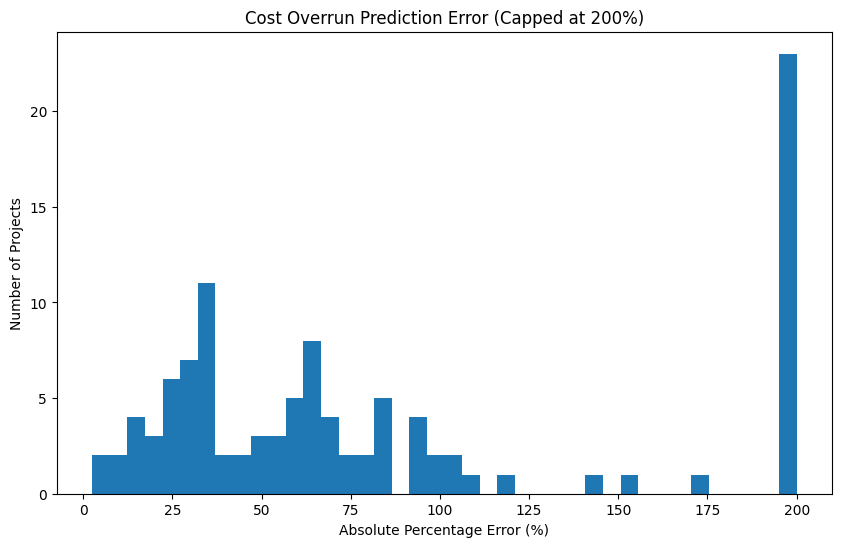

In [153]:
plot_error = error_df["Percentage_Error"].clip(upper=200)

plt.figure(figsize=(10, 6))

plt.hist(
    plot_error,
    bins=40
)

plt.xlabel("Absolute Percentage Error (%)")
plt.ylabel("Number of Projects")
plt.title("Cost Overrun Prediction Error (Capped at 200%)")

plt.show()

In [154]:
# Final Cost Overrun Probability
# XGBoost probability from the classification model

cost_overrun_probability = y_prob_xgb * 100

print("First 10 Cost Overrun Probabilities:")
print(cost_overrun_probability[:10])

First 10 Cost Overrun Probabilities:
[25.82275    26.908678    0.34453917  4.2337747  67.93509     7.2482457
 12.057617   24.162764   45.756443   27.7945    ]


In [155]:
# Convert probability into Cost Risk Score (0-100)

cost_risk_score = cost_overrun_probability

print("First 10 Cost Risk Scores:")
print(cost_risk_score[:10])

First 10 Cost Risk Scores:
[25.82275    26.908678    0.34453917  4.2337747  67.93509     7.2482457
 12.057617   24.162764   45.756443   27.7945    ]


In [156]:
# Common project data for risk scoring

risk_features = [
    "Original_Cost_Cr",
    "Cumulative_Expenditure_Cr",
    "Physical_Progress_Pct",
    "Expenditure_Pct_of_Original_Cost",
    "Ministry",
    "Sector",
    "State"
]

risk_df = df[risk_features].copy()

print("Risk Dataset Shape:", risk_df.shape)

Risk Dataset Shape: (1966, 7)


In [157]:
# Cost Overrun Probability using trained XGBoost classifier

risk_df["Cost_Overrun_Probability"] = (
    xgb_pipeline.predict_proba(risk_df)[:, 1] * 100
)

print(
    risk_df[
        ["Cost_Overrun_Probability"]
    ].head(10)
)

   Cost_Overrun_Probability
0                 27.497753
1                 77.339684
2                 30.802826
3                 21.554640
4                  1.653359
5                 70.070328
6                 32.449940
7                  0.561130
8                  0.672326
9                 13.370956


In [158]:
# Time Overrun Probability using trained Time Overrun model

risk_df["Time_Overrun_Probability"] = (
    model.predict_proba(risk_df)[:, 1] * 100
)

print(
    risk_df[
        [
            "Cost_Overrun_Probability",
            "Time_Overrun_Probability"
        ]
    ].head(10)
)

NameError: name 'model' is not defined

In [159]:
# Prepare data for Time Overrun model

time_df = df.dropna(subset=["Time_Overrun_Flag"]).copy()

time_df["Time_Overrun_Flag"] = (time_df["Time_Overrun_Flag"].astype(int))

time_X = time_df[
    [
        "Original_Cost_Cr",
        "Cumulative_Expenditure_Cr",
        "Physical_Progress_Pct",
        "Expenditure_Pct_of_Original_Cost",
        "Ministry",
        "Sector",
        "State"
    ]
]

time_y = time_df["Time_Overrun_Flag"]

print("Time Model Dataset:", time_X.shape)
print("Target Distribution:")
print(time_y.value_counts())


Time Model Dataset: (1613, 7)
Target Distribution:
Time_Overrun_Flag
1    1245
0     368
Name: count, dtype: int64


In [160]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

time_X_train, time_X_test, time_y_train, time_y_test = train_test_split(
    time_X,
    time_y,
    test_size=0.20,
    random_state=42,
    stratify=time_y
)

time_rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

time_rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", time_rf_model)
    ]
)

time_rf_pipeline.fit(
    time_X_train,
    time_y_train
)

print("Time Overrun Random Forest trained successfully!")

Time Overrun Random Forest trained successfully!


In [161]:
risk_df["Time_Overrun_Probability"] = (time_rf_pipeline.predict_proba(risk_df)[:, 1] * 100)

print(risk_df[
        [
            "Cost_Overrun_Probability",
            "Time_Overrun_Probability"
        ]
    ].head(10)
)

   Cost_Overrun_Probability  Time_Overrun_Probability
0                 27.497753                      85.0
1                 77.339684                      94.0
2                 30.802826                      98.5
3                 21.554640                     100.0
4                  1.653359                      92.5
5                 70.070328                      55.5
6                 32.449940                      23.5
7                  0.561130                      97.0
8                  0.672326                      78.5
9                 13.370956                      93.5


In [162]:
risk_df["Overall_Risk_Score"] = (
    0.5 * risk_df["Cost_Overrun_Probability"]
    + 0.5 * risk_df["Time_Overrun_Probability"]
)

print(
    risk_df[
        [
            "Cost_Overrun_Probability",
            "Time_Overrun_Probability",
            "Overall_Risk_Score"
        ]
    ].head(10)
)

   Cost_Overrun_Probability  Time_Overrun_Probability  Overall_Risk_Score
0                 27.497753                      85.0           56.248877
1                 77.339684                      94.0           85.669842
2                 30.802826                      98.5           64.651413
3                 21.554640                     100.0           60.777320
4                  1.653359                      92.5           47.076679
5                 70.070328                      55.5           62.785164
6                 32.449940                      23.5           27.974970
7                  0.561130                      97.0           48.780565
8                  0.672326                      78.5           39.586163
9                 13.370956                      93.5           53.435478


In [163]:
def get_risk_level(score):

    if score < 25:
        return "Low"

    elif score < 50:
        return "Medium"

    elif score < 75:
        return "High"

    else:
        return "Critical"


risk_df["Risk_Level"] = (
    risk_df["Overall_Risk_Score"]
    .apply(get_risk_level)
)

print(
    risk_df[
        [
            "Overall_Risk_Score",
            "Risk_Level"
        ]
    ].head(10)
)

   Overall_Risk_Score Risk_Level
0           56.248877       High
1           85.669842   Critical
2           64.651413       High
3           60.777320       High
4           47.076679     Medium
5           62.785164       High
6           27.974970     Medium
7           48.780565     Medium
8           39.586163     Medium
9           53.435478       High


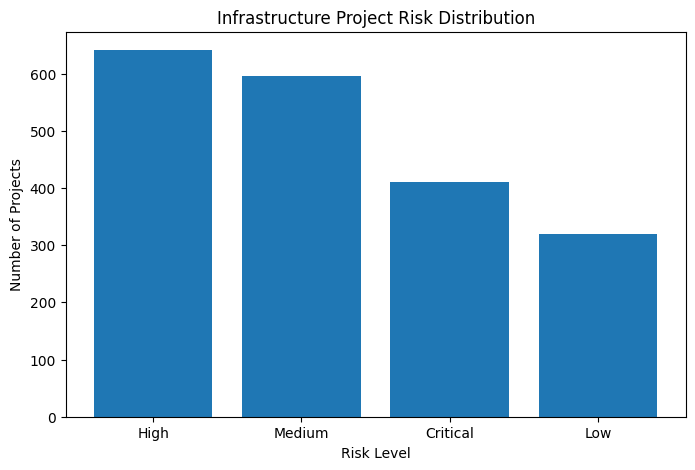

In [164]:
import matplotlib.pyplot as plt

risk_counts = risk_df["Risk_Level"].value_counts()

plt.figure(figsize=(8, 5))

plt.bar(
    risk_counts.index,
    risk_counts.values
)

plt.xlabel("Risk Level")
plt.ylabel("Number of Projects")
plt.title("Infrastructure Project Risk Distribution")

plt.show()

In [165]:
risk_results = df[
    [
        "Project_ID",
        "Project_Name",
        "Ministry",
        "Sector",
        "State"
    ]
].copy()

risk_results["Cost_Overrun_Probability"] = (
    risk_df["Cost_Overrun_Probability"].values
)

risk_results["Time_Overrun_Probability"] = (
    risk_df["Time_Overrun_Probability"].values
)

risk_results["Overall_Risk_Score"] = (
    risk_df["Overall_Risk_Score"].values
)

risk_results["Risk_Level"] = (
    risk_df["Risk_Level"].values
)

print("Risk result dataset created!")

Risk result dataset created!


In [166]:
top_10_risky = (
    risk_results
    .sort_values(
        "Overall_Risk_Score",
        ascending=False
    )
    .head(10)
)

top_10_risky

,Project_ID,Project_Name,Ministry,Sector,State,Cost_Overrun_Probability,Time_Overrun_Probability,Overall_Risk_Score,Risk_Level
1656,701410,Relining of Rajasthan feeder and Sirhind Feede...,"Department of Water Resources, River Developme...",Water Resources,Punjab,99.260979,100.0,99.630489,Critical
1645,701391,Aruna Medium Irrigation Project (Department of...,"Department of Water Resources, River Developme...",Water Resources,Maharashtra,98.910019,100.0,99.455009,Critical
1643,701383,Waghur Project (Department of water resources-...,"Department of Water Resources, River Developme...",Water Resources,Maharashtra,98.708679,100.0,99.354340,Critical
398,617302,Durgapur - Haldia Pipeline [Section-3B of JHBD...,Ministry of Petroleum & Natural Gas,Oil & Gas,West Bengal,98.459038,100.0,99.229519,Critical
969,618482,Delhi-Amritsar-Katra Expressway Phase-I Pkg-I ...,Ministry of Road Transport & Highways,Roads & Highways,Haryana,98.439514,100.0,99.219757,Critical
1562,619202,Dwarka Expressway from Km -0.600 to Km 5.300 -...,Ministry of Road Transport & Highways,Roads & Highways,Delhi,99.140396,99.0,99.070198,Critical
970,618483,Delhi-Amritsar-Katra Expressway Phase-I Pkg-II...,Ministry of Road Transport & Highways,Roads & Highways,Haryana,97.926315,100.0,98.963158,Critical
22,400102,Sri Ram Sagar Project Stage - II (Irrigation a...,"Department of Water Resources, River Developme...",Water Resources,Telangana,98.393250,99.5,98.946625,Critical
112,602579,Buxar Thermal Power Project [1320 MW] (Satluj ...,Ministry of Power,Electricity Generation,Bihar,98.259987,99.5,98.879993,Critical
1642,701377,Upper Tunga Irrigation Project (Water Resource...,"Department of Water Resources, River Developme...",Water Resources,Karnataka,98.166763,99.5,98.833382,Critical


In [167]:
top_10_risky[
    [
        "Project_ID",
        "Project_Name",
        "Sector",
        "State",
        "Cost_Overrun_Probability",
        "Time_Overrun_Probability",
        "Overall_Risk_Score",
        "Risk_Level"
    ]
].reset_index(drop=True)

,Project_ID,Project_Name,Sector,State,Cost_Overrun_Probability,Time_Overrun_Probability,Overall_Risk_Score,Risk_Level
0,701410,Relining of Rajasthan feeder and Sirhind Feede...,Water Resources,Punjab,99.260979,100.0,99.630489,Critical
1,701391,Aruna Medium Irrigation Project (Department of...,Water Resources,Maharashtra,98.910019,100.0,99.455009,Critical
2,701383,Waghur Project (Department of water resources-...,Water Resources,Maharashtra,98.708679,100.0,99.354340,Critical
3,617302,Durgapur - Haldia Pipeline [Section-3B of JHBD...,Oil & Gas,West Bengal,98.459038,100.0,99.229519,Critical
4,618482,Delhi-Amritsar-Katra Expressway Phase-I Pkg-I ...,Roads & Highways,Haryana,98.439514,100.0,99.219757,Critical
5,619202,Dwarka Expressway from Km -0.600 to Km 5.300 -...,Roads & Highways,Delhi,99.140396,99.0,99.070198,Critical
6,618483,Delhi-Amritsar-Katra Expressway Phase-I Pkg-II...,Roads & Highways,Haryana,97.926315,100.0,98.963158,Critical
7,400102,Sri Ram Sagar Project Stage - II (Irrigation a...,Water Resources,Telangana,98.393250,99.5,98.946625,Critical
8,602579,Buxar Thermal Power Project [1320 MW] (Satluj ...,Electricity Generation,Bihar,98.259987,99.5,98.879993,Critical
9,701377,Upper Tunga Irrigation Project (Water Resource...,Water Resources,Karnataka,98.166763,99.5,98.833382,Critical


In [168]:
early_warning_df = risk_results.copy()

early_warning_df = early_warning_df.merge(
    df[
        [
            "Project_ID",
            "Original_Cost_Cr",
            "Cumulative_Expenditure_Cr",
            "Physical_Progress_Pct",
            "Expenditure_Pct_of_Original_Cost"
        ]
    ],
    on="Project_ID",
    how="left"
)

early_warning_df.head()

,Project_ID,Project_Name,Ministry,Sector,State,Cost_Overrun_Probability,Time_Overrun_Probability,Overall_Risk_Score,Risk_Level,Original_Cost_Cr,Cumulative_Expenditure_Cr,Physical_Progress_Pct,Expenditure_Pct_of_Original_Cost
0,400006,Jharsuguda-Barpali-Sardega Ph II Works- Rail C...,Ministry of Railways,Railways,Odisha,27.497753,85.0,56.248877,High,808.99,743.46,40.00,91.8998
1,400010,Construction of Terminal Building & Associated...,Ministry of Civil Aviation,Aviation & Aviation Infrastructure,Ladakh,77.339684,94.0,85.669842,Critical,480.00,506.13,79.20,105.4437
2,400012,Kandla Gorakhpur LPG Pipeline (Ministry of Pet...,Ministry of Petroleum & Natural Gas,Energy Storage,"Multi-States (Gujarat, Madhya Pradesh, Uttar P...",30.802826,98.5,64.651413,High,10088.00,8585.71,95.40,85.1081
3,400013,Saturation 4G mobile coverage of Uncovered Vil...,Department of Telecommunications,Telecommunication,PAN India,21.554640,100.0,60.777320,High,26316.00,9791.80,85.00,37.2085
4,400018,HURA C OCP (ECL - CIL) (400018) (N06000275) (4...,Ministry of Coal,Coal,Jharkhand,1.653359,92.5,47.076679,Medium,859.41,455.25,63.22,52.9724


In [169]:
def generate_warning(row):

    if row["Overall_Risk_Score"] >= 75:
        return "CRITICAL EARLY WARNING"

    elif row["Overall_Risk_Score"] >= 50:
        return "HIGH EARLY WARNING"

    elif row["Overall_Risk_Score"] >= 25:
        return "MONITOR"

    else:
        return "NORMAL"


early_warning_df["Warning_Status"] = (
    early_warning_df.apply(
        generate_warning,
        axis=1
    )
)

print(
    early_warning_df[
        [
            "Project_ID",
            "Overall_Risk_Score",
            "Risk_Level",
            "Warning_Status"
        ]
    ].head(10)
)

  Project_ID  Overall_Risk_Score Risk_Level          Warning_Status
0     400006           56.248877       High      HIGH EARLY WARNING
1     400010           85.669842   Critical  CRITICAL EARLY WARNING
2     400012           64.651413       High      HIGH EARLY WARNING
3     400013           60.777320       High      HIGH EARLY WARNING
4     400018           47.076679     Medium                 MONITOR
5     400019           62.785164       High      HIGH EARLY WARNING
6     400022           27.974970     Medium                 MONITOR
7     400023           48.780565     Medium                 MONITOR
8     400033           39.586163     Medium                 MONITOR
9     400035           53.435478       High      HIGH EARLY WARNING


In [170]:
critical_projects = (
    early_warning_df[
        early_warning_df["Overall_Risk_Score"] >= 75
    ]
    .sort_values(
        "Overall_Risk_Score",
        ascending=False
    )
)

print(
    "Total Critical/High-Risk Projects:",
    len(critical_projects)
)

critical_projects.head(10)

Total Critical/High-Risk Projects: 410


,Project_ID,Project_Name,Ministry,Sector,State,Cost_Overrun_Probability,Time_Overrun_Probability,Overall_Risk_Score,Risk_Level,Original_Cost_Cr,Cumulative_Expenditure_Cr,Physical_Progress_Pct,Expenditure_Pct_of_Original_Cost,Warning_Status
1656,701410,Relining of Rajasthan feeder and Sirhind Feede...,"Department of Water Resources, River Developme...",Water Resources,Punjab,99.260979,100.0,99.630489,Critical,1441.26,2337.42,95.00,162.1789,CRITICAL EARLY WARNING
1645,701391,Aruna Medium Irrigation Project (Department of...,"Department of Water Resources, River Developme...",Water Resources,Maharashtra,98.910019,100.0,99.455009,Critical,210.45,1734.71,98.10,824.2861,CRITICAL EARLY WARNING
1643,701383,Waghur Project (Department of water resources-...,"Department of Water Resources, River Developme...",Water Resources,Maharashtra,98.708679,100.0,99.354340,Critical,1058.99,1634.36,89.57,154.3320,CRITICAL EARLY WARNING
398,617302,Durgapur - Haldia Pipeline [Section-3B of JHBD...,Ministry of Petroleum & Natural Gas,Oil & Gas,West Bengal,98.459038,100.0,99.229519,Critical,1740.00,2370.40,95.00,136.2299,CRITICAL EARLY WARNING
969,618482,Delhi-Amritsar-Katra Expressway Phase-I Pkg-I ...,Ministry of Road Transport & Highways,Roads & Highways,Haryana,98.439514,100.0,99.219757,Critical,1866.49,1081.56,99.91,57.9462,CRITICAL EARLY WARNING
1562,619202,Dwarka Expressway from Km -0.600 to Km 5.300 -...,Ministry of Road Transport & Highways,Roads & Highways,Delhi,99.140396,99.0,99.070198,Critical,2144.67,3106.86,98.80,144.8642,CRITICAL EARLY WARNING
970,618483,Delhi-Amritsar-Katra Expressway Phase-I Pkg-II...,Ministry of Road Transport & Highways,Roads & Highways,Haryana,97.926315,100.0,98.963158,Critical,1533.87,971.09,99.89,63.3098,CRITICAL EARLY WARNING
22,400102,Sri Ram Sagar Project Stage - II (Irrigation a...,"Department of Water Resources, River Developme...",Water Resources,Telangana,98.393250,99.5,98.946625,Critical,736.13,971.47,97.00,131.9699,CRITICAL EARLY WARNING
112,602579,Buxar Thermal Power Project [1320 MW] (Satluj ...,Ministry of Power,Electricity Generation,Bihar,98.259987,99.5,98.879993,Critical,10439.09,13479.85,94.79,129.1286,CRITICAL EARLY WARNING
1642,701377,Upper Tunga Irrigation Project (Water Resource...,"Department of Water Resources, River Developme...",Water Resources,Karnataka,98.166763,99.5,98.833382,Critical,770.16,1515.60,99.32,196.7903,CRITICAL EARLY WARNING


In [171]:
def generate_warning_reasons(row):

    reasons = []

    if row["Time_Overrun_Probability"] >= 75:
        reasons.append("High schedule delay risk")

    if row["Cost_Overrun_Probability"] >= 75:
        reasons.append("High cost overrun risk")

    if (
        pd.notna(row["Physical_Progress_Pct"])
        and row["Physical_Progress_Pct"] < 50
    ):
        reasons.append("Low physical progress")

    if (
        pd.notna(row["Expenditure_Pct_of_Original_Cost"])
        and pd.notna(row["Physical_Progress_Pct"])
        and row["Expenditure_Pct_of_Original_Cost"]
        > row["Physical_Progress_Pct"] + 10
    ):
        reasons.append(
            "Expenditure is significantly ahead of physical progress"
        )

    if len(reasons) == 0:
        reasons.append("No major warning indicator detected")

    return reasons

In [172]:
early_warning_df["Warning_Reasons"] = (
    early_warning_df.apply(
        generate_warning_reasons,
        axis=1
    )
)

early_warning_df[
    [
        "Project_ID",
        "Risk_Level",
        "Warning_Status",
        "Warning_Reasons"
    ]
].head(10)

,Project_ID,Risk_Level,Warning_Status,Warning_Reasons
0,400006,High,HIGH EARLY WARNING,"[High schedule delay risk, Low physical progre..."
1,400010,Critical,CRITICAL EARLY WARNING,"[High schedule delay risk, High cost overrun r..."
2,400012,High,HIGH EARLY WARNING,[High schedule delay risk]
3,400013,High,HIGH EARLY WARNING,[High schedule delay risk]
4,400018,Medium,MONITOR,[High schedule delay risk]
5,400019,High,HIGH EARLY WARNING,"[Low physical progress, Expenditure is signifi..."
6,400022,Medium,MONITOR,"[Low physical progress, Expenditure is signifi..."
7,400023,Medium,MONITOR,"[High schedule delay risk, Low physical progress]"
8,400033,Medium,MONITOR,"[High schedule delay risk, Low physical progress]"
9,400035,High,HIGH EARLY WARNING,[High schedule delay risk]


In [173]:
early_warning_df["Warning_Message"] = (
    early_warning_df["Warning_Reasons"]
    .apply(lambda x: " | ".join(x))
)

early_warning_df[
    [
        "Project_ID",
        "Risk_Level",
        "Warning_Message"
    ]
].head(10)

,Project_ID,Risk_Level,Warning_Message
0,400006,High,High schedule delay risk | Low physical progre...
1,400010,Critical,High schedule delay risk | High cost overrun r...
2,400012,High,High schedule delay risk
3,400013,High,High schedule delay risk
4,400018,Medium,High schedule delay risk
5,400019,High,Low physical progress | Expenditure is signifi...
6,400022,Medium,Low physical progress | Expenditure is signifi...
7,400023,Medium,High schedule delay risk | Low physical progress
8,400033,Medium,High schedule delay risk | Low physical progress
9,400035,High,High schedule delay risk
